# Simple six-parameter Bayesian inference with NumPyro

This notebook uses the basic structure emphasized in Chapter 3 of *Bayes Rules!*:

\[
\text{posterior} \propto \text{likelihood}\times\text{prior}.
\]

For this detector problem:

1. **Prior:** bounded distributions for \(a_1,\ldots,a_6\).
2. **Data model:** the six-parameter spectrum is folded through the DRM.
3. **Likelihood:** the 200 detector values are modeled around that prediction.
4. **Posterior:** NumPyro's NUTS sampler draws \(a_1,\ldots,a_6\).

\[
s(E)=a_1e^{-a_2E}+a_3\exp\left[-\frac{(E-a_4)^2}{a_5E+a_6/E}\right].
\]

There is **no neural network** and **no training set**. `data_utils.py` generates one synthetic 200×1 vector, and NumPyro infers the six parameters from that vector.

## Install once

```bash
python -m pip install numpyro pandas matplotlib openpyxl
```

NumPyro uses JAX. Native Windows CPU support may work, but WSL is a practical fallback if JAX installation fails.

In [14]:
# Uncomment once if needed:
# %pip install numpyro pandas matplotlib openpyxl

## Imports and load `data_utils.py`

In [15]:
from pathlib import Path
import importlib.util
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
from jax import random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

jax.config.update("jax_enable_x64", True)


def load_data_utils():
    exact = Path("data_utils.py")
    if exact.exists():
        selected = exact
    else:
        candidates = sorted(Path.cwd().glob("data_utils*.py"))
        if len(candidates) == 0:
            raise FileNotFoundError("Place data_utils.py in the notebook directory.")
        if len(candidates) > 1:
            raise RuntimeError(
                "Multiple data_utils files found. Rename the intended one to data_utils.py: "
                + str([str(p) for p in candidates])
            )
        selected = candidates[0]

    spec = importlib.util.spec_from_file_location("data_utils_runtime", selected)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not import {selected}")

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    print("Loaded:", selected.resolve())
    return module


du = load_data_utils()

if np.asarray(du.PFF_PARAM_SAMPLING).shape != (6, 4):
    raise ValueError("PFF_PARAM_SAMPLING must have shape (6, 4).")

print("JAX devices:", jax.devices())
print("NumPyro:", numpyro.__version__)

Loaded: C:\Users\aayan\OneDrive\Documents\GitHub\SAS-Analysis-Laser\data_utils.py
JAX devices: [CpuDevice(id=0)]
NumPyro: 0.21.0


## Configuration

In [16]:
DRM_XLSX_PATH = Path("res/drm/200x200.xlsx")
NUM_ENERGY_BINS = 100
SEED = 42

# Generate a bump-present example so all six parameters affect the data.
BUMP_FRACTION = 1

signature = inspect.signature(du.generate_spectrum_batch)
NOISE_GAIN = float(signature.parameters["noise_gain"].default)
READ_FRAC = float(signature.parameters["read_frac"].default)
MULT_FRAC = float(signature.parameters["mult_frac"].default)

# Kept off because the simple likelihood below does not model clipping.
SAT_FRACTION = 0.05

NUM_WARMUP = 1000
NUM_SAMPLES = 2000
NUM_CHAINS = 4

print("Noise settings:", NOISE_GAIN, READ_FRAC, MULT_FRAC)

Noise settings: 5.0 0.02 0.01


## Load and bin the DRM

In [17]:
drm = du.load_drm(str(DRM_XLSX_PATH))
drm_binned = du.bin_drm(drm, NUM_ENERGY_BINS).astype(np.float64)
energy_bins = du.mev_bin_centers(NUM_ENERGY_BINS).astype(np.float64)

print("DRM:", drm.shape)
print("Binned DRM:", drm_binned.shape)
print("Energy bins:", energy_bins.shape)

DRM: (200, 200)
Binned DRM: (200, 100)
Energy bins: (100,)


Spectra shape: (50, 100)
Parameter shape: (50, 6)
Clean signal shape: (50, 200)


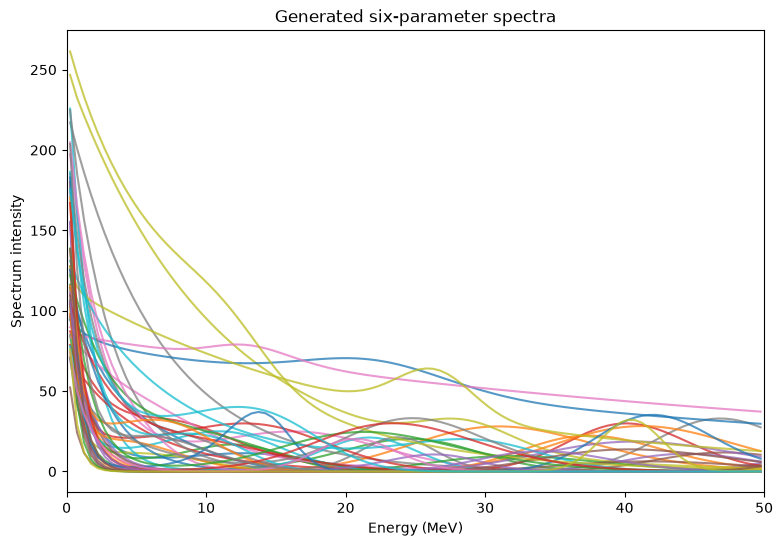

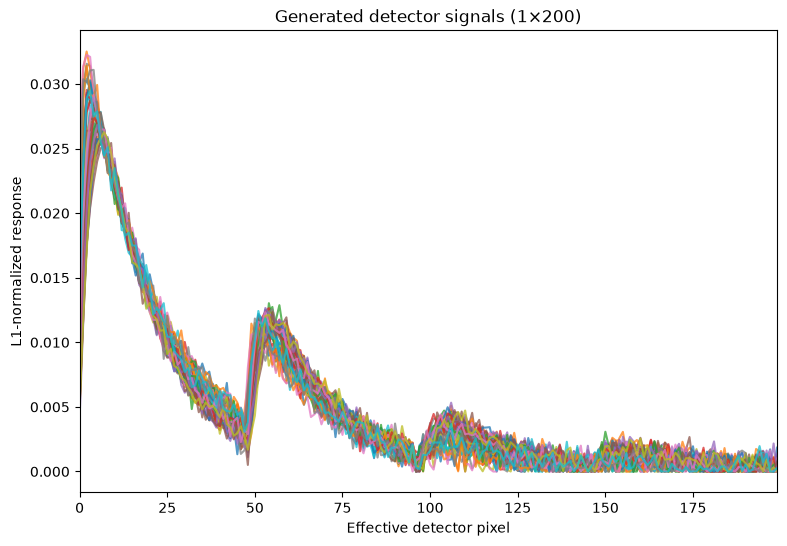

In [18]:
# ================================================================
# Plot generated spectra and corresponding 200-channel signals
# ================================================================

N_PLOT_SAMPLES = 50
PLOT_SEED = 123

plot_rng = np.random.default_rng(
    PLOT_SEED
)

# ------------------------------------------------
# 1. Generate six-parameter spectra and parameters
# ------------------------------------------------

generated_spectra, generated_parameters = (
    du.sample_pff_spectra(
        n_samples=N_PLOT_SAMPLES,
        energy_bins=energy_bins,
        rng=plot_rng,
        bump_fraction=1.0,  # every example has a bump
    )
)

print(
    "Spectra shape:",
    generated_spectra.shape,
)
# Expected: (50, 50)

print(
    "Parameter shape:",
    generated_parameters.shape,
)
# Expected: (50, 6)


# ------------------------------------------------
# 2. Fold spectra through the DRM
# ------------------------------------------------

clean_signals = (
    drm_binned
    @ generated_spectra.T
).T

print(
    "Clean signal shape:",
    clean_signals.shape,
)
# Expected: (50, 200)


# ------------------------------------------------
# 3. Apply data_utils detector noise
# ------------------------------------------------

noisy_signals = du.add_detector_noise(
    clean_signals,
    plot_rng,
    noise_gain=NOISE_GAIN,
    read_frac=READ_FRAC,
    mult_frac=MULT_FRAC,
)


# Optional saturation augmentation.
# Keep this at 0.0 for the simplest graph.
PLOT_SAT_FRACTION = 0.0

noisy_signals, _ = du.apply_saturation(
    noisy_signals,
    plot_rng,
    sat_fraction=PLOT_SAT_FRACTION,
    ceil_low=du.SAT_CEIL_LOW,
    ceil_high=du.SAT_CEIL_HIGH,
)


# ------------------------------------------------
# 4. Normalize signals to sum to one
# ------------------------------------------------

signals_l1 = (
    noisy_signals
    / np.maximum(
        noisy_signals.sum(
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )
)


# ------------------------------------------------
# Graph 1: generated spectra
# ------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

for index in range(
    N_PLOT_SAMPLES
):
    plt.plot(
        energy_bins,
        generated_spectra[index],
        alpha=0.75,
    )

plt.title(
    "Generated six-parameter spectra"
)

plt.xlabel(
    "Energy (MeV)"
)

plt.ylabel(
    "Spectrum intensity"
)

plt.xlim(
    0,
    50,
)

plt.show()


# ------------------------------------------------
# Graph 2: corresponding detector signals
# ------------------------------------------------

detector_channels = np.arange(
    200
)

plt.figure(
    figsize=(9, 6)
)

for index in range(
    N_PLOT_SAMPLES
):
    plt.plot(
        detector_channels,
        signals_l1[index],
        alpha=0.75,
    )

plt.title(
    "Generated detector signals (1×200)"
)

plt.xlabel(
    "Effective detector pixel"
)

plt.ylabel(
    "L1-normalized response"
)

plt.xlim(
    0,
    199,
)

plt.show()


## Generate one synthetic 200×1 shape observation

The synthetic spectrum is still generated from the original six physical PFF
parameters so there is a known ground truth. For inference, however, the detector
vector is **L1-normalized**, exactly like the real-shot model.

This removes the unidentifiable common amplitude scale and lets the synthetic
validation fit the same shape parameters used for real shots:

\[
r=\frac{a_3}{a_1},\qquad a_2,\ a_4,\ a_5,\ a_6.
\]

The true value of \(r\) is calculated from the generated \(a_1\) and \(a_3\).


Input shape: (200, 1)
L1 sum: 1.0


,parameter,true_value
0,r,0.152403
1,a2,1.427241
2,a4,43.514118
3,a5,1.379398
4,a6,488.895968


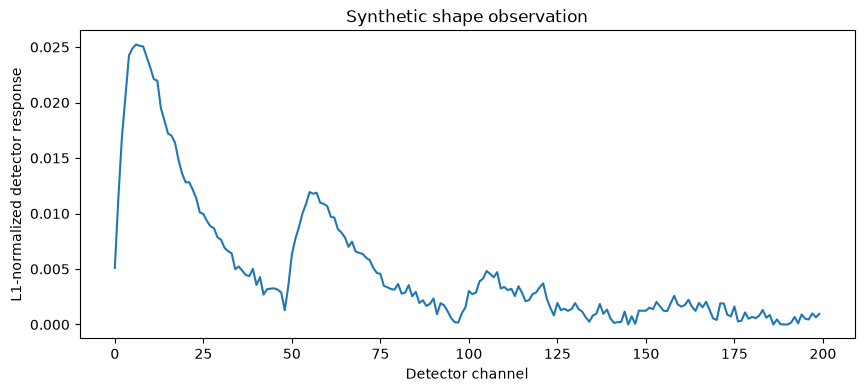

In [19]:

rng = np.random.default_rng(SEED)

# Generate one spectrum from the original six-parameter physical family.
spectra, parameters = du.sample_pff_spectra(
    n_samples=1,
    energy_bins=energy_bins,
    rng=rng,
    bump_fraction=BUMP_FRACTION,
)

true_spectrum = spectra[0]
true_parameters = parameters[0]

# True relative-amplitude parameter used by the shape-only inference.
true_r = float(true_parameters[2] / true_parameters[0])

true_shape_parameters = {
    "r": true_r,
    "a2": float(true_parameters[1]),
    "a4": float(true_parameters[3]),
    "a5": float(true_parameters[4]),
    "a6": float(true_parameters[5]),
}

clean_detector = drm_binned @ true_spectrum

observed_vector = du.add_detector_noise(
    clean_detector[None, :],
    rng,
    noise_gain=NOISE_GAIN,
    read_frac=READ_FRAC,
    mult_frac=MULT_FRAC,
)[0]

# Match the real-shot inference: compare detector SHAPE rather than absolute scale.
observed_vector_l1 = (
    observed_vector
    / max(float(observed_vector.sum()), 1e-12)
)

observed_vector_200x1 = observed_vector_l1.reshape(200, 1)

print("Input shape:", observed_vector_200x1.shape)
print("L1 sum:", observed_vector_l1.sum())

display(pd.DataFrame({
    "parameter": ["r", "a2", "a4", "a5", "a6"],
    "true_value": [
        true_shape_parameters["r"],
        true_shape_parameters["a2"],
        true_shape_parameters["a4"],
        true_shape_parameters["a5"],
        true_shape_parameters["a6"],
    ],
}))

plt.figure(figsize=(10, 4))
plt.plot(observed_vector_l1)
plt.xlabel("Detector channel")
plt.ylabel("L1-normalized detector response")
plt.title("Synthetic shape observation")
plt.show()



## Prior, likelihood, and posterior

This synthetic validation now uses the **same identifiable shape parameterization**
as the real-shot inference.

- **Shape parameters:** \(r=a_3/a_1,\ a_2,\ a_4,\ a_5,\ a_6\).
- **Relative-amplitude prior:** the prior for \(r\) is derived from the original
  \(a_3\) and \(a_1\) sampling distributions.
- **Forward model:** build
  \[
  s(E)=e^{-a_2E}
  +r\exp\!\left[-\frac{(E-a_4)^2}{a_5E+a_6/E}\right],
  \]
  fold it through the DRM, and L1-normalize the detector prediction.
- **Likelihood:** Student-\(t\), matching the robust real-shot shape likelihood.
- **Posterior:** NumPyro NUTS samples the nonlinear posterior numerically.

Because the synthetic observation and forward prediction are both L1-normalized,
the common amplitude \(a_1\) is intentionally not inferred.


In [20]:

parameter_sampling = np.asarray(
    du.PFF_PARAM_SAMPLING,
    dtype=np.float64,
)

display(pd.DataFrame(
    parameter_sampling,
    index=["a1", "a2", "a3", "a4", "a5", "a6"],
    columns=["mean", "std", "low", "high"],
))

drm_jax = jnp.asarray(drm_binned)
energy_jax = jnp.asarray(energy_bins)

prior_mean = jnp.asarray(parameter_sampling[:, 0])
prior_std = jnp.asarray(parameter_sampling[:, 1])
prior_low = jnp.asarray(parameter_sampling[:, 2])
prior_high = jnp.asarray(parameter_sampling[:, 3])

# ------------------------------------------------------------------
# Relative bump-amplitude prior: r = a3 / a1
# ------------------------------------------------------------------
R_TRAIN_PRIOR_MEAN = float(
    parameter_sampling[2, 0]
    / parameter_sampling[0, 0]
)

# First-order uncertainty propagation for the ratio a3/a1.
R_TRAIN_PRIOR_STD = float(
    R_TRAIN_PRIOR_MEAN
    * np.sqrt(
        (parameter_sampling[2, 1] / parameter_sampling[2, 0]) ** 2
        + (parameter_sampling[0, 1] / parameter_sampling[0, 0]) ** 2
    )
)
R_TRAIN_PRIOR_STD = max(
    R_TRAIN_PRIOR_STD,
    1e-4,
)

R_TRAIN_PRIOR_LOW = 0.0
R_TRAIN_PRIOR_HIGH = float(
    parameter_sampling[2, 3]
    / parameter_sampling[0, 2]
)

TRAIN_STUDENT_T_DF = 4.0
TRAIN_SIGMA_PRIOR_SCALE = 0.01

print(
    "Synthetic relative-amplitude prior:",
    f"r ~ TruncatedNormal(mean={R_TRAIN_PRIOR_MEAN:.4f}, "
    f"std={R_TRAIN_PRIOR_STD:.4f}, "
    f"low={R_TRAIN_PRIOR_LOW:.4f}, "
    f"high={R_TRAIN_PRIOR_HIGH:.4f})",
)


def pff_relative(r, a2, a4, a5, a6):
    # Shape-only PFF parameterization.
    # The exponential amplitude is fixed to 1, and r = a3 / a1.
    E = jnp.maximum(
        energy_jax,
        1e-12,
    )

    denominator = jnp.maximum(
        a5 * E + a6 / E,
        1e-12,
    )

    return (
        jnp.exp(-a2 * E)
        + r
        * jnp.exp(
            -((E - a4) ** 2)
            / denominator
        )
    )


def bayesian_model(detector_observation=None):
    # --------------------------------------------------------------
    # 1. Priors on identifiable SHAPE parameters
    # --------------------------------------------------------------
    r = numpyro.sample(
        "r",
        dist.TruncatedNormal(
            R_TRAIN_PRIOR_MEAN,
            R_TRAIN_PRIOR_STD,
            low=R_TRAIN_PRIOR_LOW,
            high=R_TRAIN_PRIOR_HIGH,
        ),
    )

    a2 = numpyro.sample(
        "a2",
        dist.TruncatedNormal(
            prior_mean[1],
            prior_std[1],
            low=prior_low[1],
            high=prior_high[1],
        ),
    )

    a4 = numpyro.sample(
        "a4",
        dist.TruncatedNormal(
            prior_mean[3],
            prior_std[3],
            low=prior_low[3],
            high=prior_high[3],
        ),
    )

    a5 = numpyro.sample(
        "a5",
        dist.TruncatedNormal(
            prior_mean[4],
            prior_std[4],
            low=prior_low[4],
            high=prior_high[4],
        ),
    )

    a6 = numpyro.sample(
        "a6",
        dist.TruncatedNormal(
            prior_mean[5],
            prior_std[5],
            low=prior_low[5],
            high=prior_high[5],
        ),
    )

    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(
            TRAIN_SIGMA_PRIOR_SCALE
        ),
    )

    # --------------------------------------------------------------
    # 2. Forward model and L1 normalization
    # --------------------------------------------------------------
    spectrum = pff_relative(
        r,
        a2,
        a4,
        a5,
        a6,
    )

    predicted_raw = jnp.maximum(
        drm_jax @ spectrum,
        1e-12,
    )

    predicted_l1 = (
        predicted_raw
        / jnp.sum(predicted_raw)
    )

    # --------------------------------------------------------------
    # 3. Robust shape likelihood
    # --------------------------------------------------------------
    numpyro.sample(
        "obs",
        dist.StudentT(
            df=TRAIN_STUDENT_T_DF,
            loc=predicted_l1,
            scale=sigma + 1e-7,
        ).to_event(1),
        obs=detector_observation,
    )


,mean,std,low,high
a1,150.0,100.0,50.000000,250.0
a2,0.3,1.0,0.010000,2.0
a3,20.0,10.0,0.000000,50.0
a4,20.0,25.0,1.000000,75.0
a5,0.5,1.0,0.000001,10.0
a6,100.0,500.0,0.000001,10000.0


Synthetic relative-amplitude prior: r ~ TruncatedNormal(mean=0.1333, std=0.1111, low=0.0000, high=1.0000)


## Run NUTS

In [21]:

observed_jax = jnp.asarray(
    observed_vector_200x1.reshape(200)
)

kernel = NUTS(
    bayesian_model,
    target_accept_prob=0.90,
    dense_mass=True,
)

mcmc = MCMC(
    kernel,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    chain_method="sequential",
    progress_bar=True,
)

mcmc.run(
    random.key(SEED + 1),
    detector_observation=observed_jax,
)

# Standard NumPyro parameter diagnostics.
mcmc.print_summary()

# --------------------------------------------------------------
# Explicit divergence report for the SYNTHETIC r-model validation
# --------------------------------------------------------------
training_extra_fields = mcmc.get_extra_fields(
    group_by_chain=True
)

training_diverging = np.asarray(
    training_extra_fields["diverging"]
)

training_total_divergences = int(
    training_diverging.sum()
)

print("\n" + "=" * 72)
print("SYNTHETIC r-MODEL NUTS DIVERGENCE DIAGNOSTIC")
print("=" * 72)
print(
    f"Total divergences: "
    f"{training_total_divergences}"
    f"/{training_diverging.size}"
)

if training_diverging.ndim >= 2:
    for chain_index in range(
        training_diverging.shape[0]
    ):
        chain_divergences = int(
            training_diverging[
                chain_index
            ].sum()
        )

        print(
            f"Chain {chain_index + 1}: "
            f"{chain_divergences}"
            f"/{training_diverging.shape[1]}"
        )

if training_total_divergences == 0:
    print("Status: GOOD — no divergent transitions detected.")
else:
    print(
        "Status: WARNING — divergent transitions detected. "
        "Inspect posterior geometry and consider increasing "
        "target_accept_prob after checking the model."
    )

print("=" * 72)

posterior_samples = mcmc.get_samples(
    group_by_chain=False
)


sample: 100%|██████████| 3000/3000 [00:01<00:00, 1560.11it/s, 7 steps of size 2.48e-01. acc. prob=0.96] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a2      1.07      0.36      1.02      0.51      1.68   2780.33      1.00
        a4     45.17      2.36     44.77     41.70     48.80   2643.56      1.00
        a5      1.17      0.70      1.09      0.00      2.13   3709.34      1.00
        a6    454.82    323.93    391.67      0.99    914.51   6205.34      1.00
         r      0.20      0.07      0.19      0.08      0.31   5691.65      1.00
     sigma      0.00      0.00      0.00      0.00      0.00   6671.40      1.00

Number of divergences: 0

SYNTHETIC r-MODEL NUTS DIVERGENCE DIAGNOSTIC
Total divergences: 0/8000
Chain 1: 0/2000
Chain 2: 0/2000
Chain 3: 0/2000
Chain 4: 0/2000
Status: GOOD — no divergent transitions detected.


## Posterior summaries and distributions

,parameter,true_value,posterior_mean,posterior_std,posterior_median,credible_2.5%,credible_97.5%
0,r,0.152403,0.197031,0.074953,0.186575,0.081402,0.364854
1,a2,1.427241,1.069380,0.361146,1.017703,0.514658,1.868030
2,a4,43.514118,45.172709,2.357158,44.769163,41.690472,50.931683
3,a5,1.379398,1.166681,0.703042,1.094746,0.104638,2.736018
4,a6,488.895968,454.817644,323.909648,391.667092,21.284074,1220.552283
5,sigma,NaN,0.000378,0.000024,0.000377,0.000334,0.000426


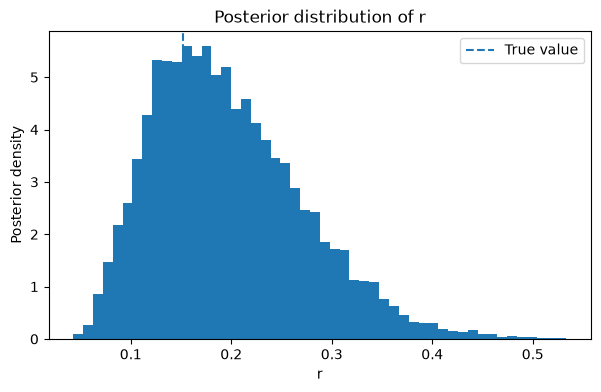

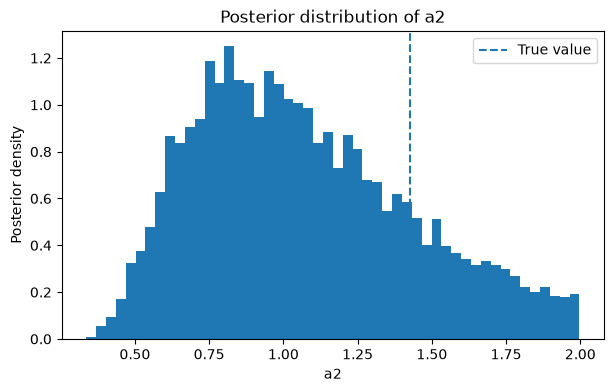

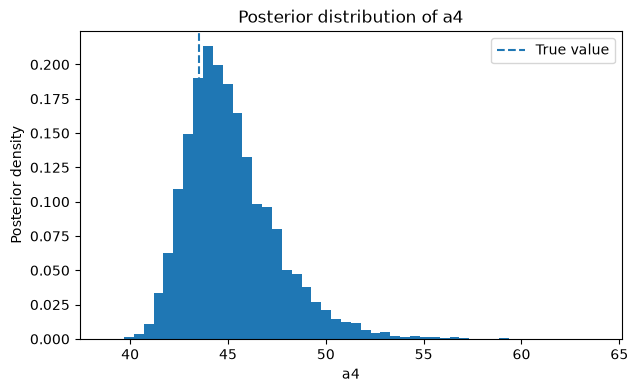

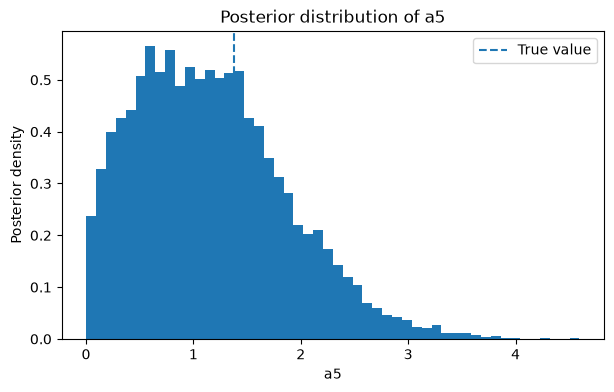

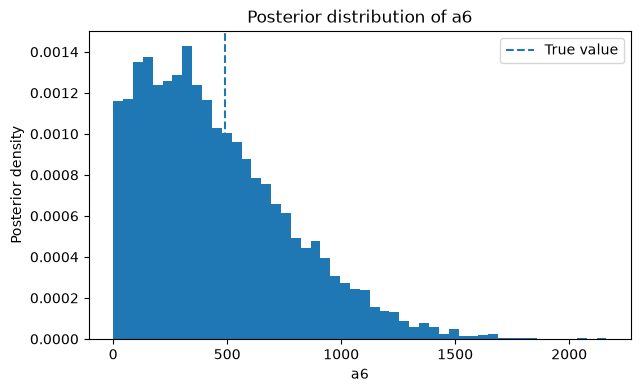

In [22]:

parameter_names = [
    "r",
    "a2",
    "a4",
    "a5",
    "a6",
]

true_parameter_values = {
    "r": true_shape_parameters["r"],
    "a2": true_shape_parameters["a2"],
    "a4": true_shape_parameters["a4"],
    "a5": true_shape_parameters["a5"],
    "a6": true_shape_parameters["a6"],
}

rows = []

for name in parameter_names:
    values = np.asarray(
        posterior_samples[name]
    )

    rows.append({
        "parameter": name,
        "true_value": true_parameter_values[name],
        "posterior_mean": values.mean(),
        "posterior_std": values.std(),
        "posterior_median": np.median(values),
        "credible_2.5%": np.percentile(values, 2.5),
        "credible_97.5%": np.percentile(values, 97.5),
    })

# sigma is a likelihood scale rather than a PFF shape parameter.
sigma_values = np.asarray(
    posterior_samples["sigma"]
)

rows.append({
    "parameter": "sigma",
    "true_value": np.nan,
    "posterior_mean": sigma_values.mean(),
    "posterior_std": sigma_values.std(),
    "posterior_median": np.median(sigma_values),
    "credible_2.5%": np.percentile(sigma_values, 2.5),
    "credible_97.5%": np.percentile(sigma_values, 97.5),
})

posterior_summary = pd.DataFrame(
    rows
)

display(
    posterior_summary
)

for name in parameter_names:
    values = np.asarray(
        posterior_samples[name]
    )

    plt.figure(
        figsize=(7, 4)
    )

    plt.hist(
        values,
        bins=50,
        density=True,
    )

    plt.axvline(
        true_parameter_values[name],
        linestyle="--",
        label="True value",
    )

    plt.xlabel(
        name
    )

    plt.ylabel(
        "Posterior density"
    )

    plt.title(
        f"Posterior distribution of {name}"
    )

    plt.legend()
    plt.show()


## Posterior-predictive check

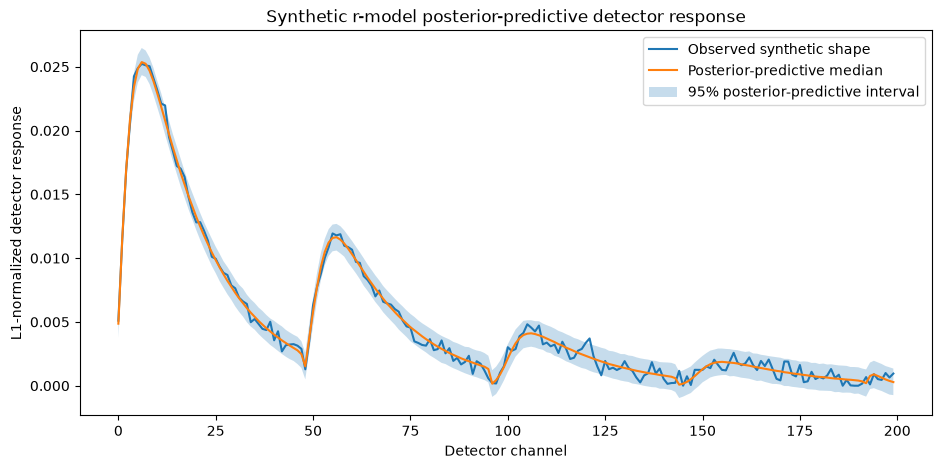

In [23]:

predictive = Predictive(
    bayesian_model,
    posterior_samples=posterior_samples,
    return_sites=["obs"],
)

posterior_predictive = predictive(
    random.key(SEED + 2),
    detector_observation=None,
)

predicted_vectors = np.asarray(
    posterior_predictive["obs"]
)

median = np.median(
    predicted_vectors,
    axis=0,
)

low = np.percentile(
    predicted_vectors,
    2.5,
    axis=0,
)

high = np.percentile(
    predicted_vectors,
    97.5,
    axis=0,
)

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    observed_vector_l1,
    label="Observed synthetic shape",
)

plt.plot(
    median,
    label="Posterior-predictive median",
)

plt.fill_between(
    np.arange(200),
    low,
    high,
    alpha=0.25,
    label="95% posterior-predictive interval",
)

plt.xlabel(
    "Detector channel"
)

plt.ylabel(
    "L1-normalized detector response"
)

plt.title(
    "Synthetic r-model posterior-predictive detector response"
)

plt.legend()
plt.show()


## Save results

In [24]:

pd.DataFrame({
    name: np.asarray(
        posterior_samples[name]
    )
    for name in (
        parameter_names
        + ["sigma"]
    )
}).to_csv(
    "numpyro_relative_r_posterior_samples.csv",
    index=False,
)

posterior_summary.to_csv(
    "numpyro_relative_r_posterior_summary.csv",
    index=False,
)

np.savez(
    "numpyro_relative_r_results.npz",
    observed_vector_l1=observed_vector_l1,
    observed_vector_raw=observed_vector,
    clean_detector=clean_detector,
    true_spectrum=true_spectrum,
    true_parameters_six=true_parameters,
    true_r=true_r,
    energy_bins=energy_bins,
    drm_binned=drm_binned,
    training_total_divergences=training_total_divergences,
    **{
        name: np.asarray(
            posterior_samples[name]
        )
        for name in (
            parameter_names
            + ["sigma"]
        )
    },
)

print(
    "Saved relative-r posterior samples, summary, "
    "divergence count, and NPZ results."
)


Saved relative-r posterior samples, summary, divergence count, and NPZ results.



## Later use with a real 200×1 vector

The synthetic validation above now uses the same **shape-only**
\(r,a_2,a_4,a_5,a_6\) parameterization as the real-shot section below.

For an actual detector vector, the dedicated real-shot inference cell is preferred
because it also handles saturation masks and saves the shot-specific plots/results.

Absolute source amplitude is not inferred by this shape-only model because both
the observed and modeled detector vectors are L1-normalized.



## Why this follows Chapter 3 without using Beta-Binomial conjugacy

The Chapter 3 example has a Beta prior and Binomial data, so its posterior has a
closed-form Beta distribution. Here, the unknown spectrum shape is described by
five continuous physical parameters,

\[
r,\ a_2,\ a_4,\ a_5,\ a_6,
\]

plus the likelihood scale \(\sigma\). The DRM forward relationship is nonlinear,
so the posterior is not available in a simple closed form. NumPyro's NUTS
algorithm numerically draws from that posterior while preserving the same
prior-likelihood-posterior logic.

The training-validation cell now prints the total NUTS divergence count explicitly,
including a per-chain count when multiple chains are used.



## Real-shot inference with relative bump amplitude

The following cell reads the same 200-channel shot CSV files used by
the prior CNN inference script. It runs a separate NumPyro NUTS
posterior for each shot and saves posterior tables and figures.

The real-shot likelihood compares **L1-normalized detector shapes**. Under L1
normalization, multiplying both `a1` and `a3` by the same positive constant
leaves the predicted detector shape unchanged, so their common amplitude scale
is not identifiable from these data. The model therefore fixes the exponential
amplitude to 1 and samples the relative bump amplitude

\[
r = \frac{a_3}{a_1}.
\]

The fitted real-shot shape parameters are therefore `r, a2, a4, a5, a6`
(plus the likelihood scale `sigma`).

The synthetic validation immediately above now uses this same relative-amplitude
shape parameterization and prints its NUTS divergence count explicitly, making
the synthetic and real-shot sampler diagnostics directly comparable.


In [25]:
# ============================================================================
# REAL-SHOT INFERENCE CELL
# Synthetic validation above now uses the same r parameterization.
#
# Run the earlier notebook cells first so these objects already exist:
#   du, drm_binned, energy_bins, parameter_sampling,
#   prior_mean, prior_std, prior_low, prior_high,
#   jax, jnp, random, numpyro, dist, MCMC, NUTS,
#   np, pd, plt
#
# This cell:
#   - reads 200-channel *_proc_vector_ch.csv and *_proc_vector_cv.csv files
#   - L1-normalizes real and modeled detector responses
#   - runs a new NumPyro NUTS posterior for each shot
#   - ignores saturation-corrected channels in the likelihood when a mask exists
#   - saves posterior samples and parameter summaries
#   - saves detector/spectrum/residual and parameter-posterior figures
#
# Important:
#   Because the fit uses L1-normalized response shapes, a common multiplicative
#   scale on a1 and a3 cancels exactly. The real-shot model therefore fixes
#   a1 = 1 and samples only r = a3/a1, removing that non-identifiable direction.
# ============================================================================

from pathlib import Path
import warnings


# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------

SHOT_NUM_WARMUP = 750
SHOT_NUM_SAMPLES = 1_000
SHOT_NUM_CHAINS = 1
SHOT_TARGET_ACCEPT = 0.98
SHOT_MAX_PREDICTIVE_DRAWS = 1_000

# Robust likelihood for normalized detector shapes.
SHOT_STUDENT_T_DF = 4.0
SHOT_SIGMA_PRIOR_SCALE = 0.01

# Relative bump-amplitude prior: r = a3 / a1.
# The mean is the ratio of the original PFF prior means. The standard deviation
# uses first-order uncertainty propagation for a ratio of independent a3 and a1.
# Bounds come from the broadest ratio allowed by the original positive bounds.
R_PRIOR_MEAN = float(
    parameter_sampling[2, 0] / parameter_sampling[0, 0]
)
R_PRIOR_STD = float(
    R_PRIOR_MEAN
    * np.sqrt(
        (parameter_sampling[2, 1] / parameter_sampling[2, 0]) ** 2
        + (parameter_sampling[0, 1] / parameter_sampling[0, 0]) ** 2
    )
)
R_PRIOR_STD = max(R_PRIOR_STD, 1e-4)
R_PRIOR_LOW = 0.0
R_PRIOR_HIGH = float(
    parameter_sampling[2, 3] / parameter_sampling[0, 2]
)

print(
    "Real-shot relative-amplitude prior:",
    f"r ~ TruncatedNormal(mean={R_PRIOR_MEAN:.4f}, "
    f"std={R_PRIOR_STD:.4f}, "
    f"low={R_PRIOR_LOW:.4f}, high={R_PRIOR_HIGH:.4f})",
)

SHOT_RESULTS_DIR = Path(
    "numpyro_shot_results_relative_r"
)
SHOT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEFAULT_SHOTS = [
    "res/test_images/10084/10084_proc_vector_ch.csv",
    "res/test_images/11674/11674_proc_vector_ch.csv",
    "res/test_images/11733/11733_proc_vector_ch.csv",
    "res/test_images/11705/11705_proc_vector_ch.csv",
    "res/test_images/11707/11707_proc_vector_ch.csv",
    "res/test_images/11716/11716_proc_vector_ch.csv",

    "res/test_images/10084/10084_proc_vector_cv.csv",
    "res/test_images/11674/11674_proc_vector_cv.csv",
    "res/test_images/11733/11733_proc_vector_cv.csv",
    "res/test_images/11705/11705_proc_vector_cv.csv",
    "res/test_images/11707/11707_proc_vector_cv.csv",
    "res/test_images/11716/11716_proc_vector_cv.csv",
]

# Replace this list to infer only selected shots.
SHOT_PATHS = DEFAULT_SHOTS


# ----------------------------------------------------------------------------
# Input helpers
# ----------------------------------------------------------------------------

def load_shot_signal(
    csv_path: str | Path,
) -> np.ndarray:
    """
    Load one 200-channel detector vector.

    This matches the earlier inference script by reading the final CSV column.
    """
    csv_path = Path(csv_path)

    dataframe = pd.read_csv(
        csv_path
    )

    signal = (
        dataframe.iloc[:, -1]
        .to_numpy(
            dtype=np.float64
        )
        .reshape(-1)
    )

    if signal.shape != (200,):
        raise ValueError(
            f"{csv_path}: expected 200 values, received {signal.shape}."
        )

    if not np.all(
        np.isfinite(signal)
    ):
        raise ValueError(
            f"{csv_path}: signal contains NaN or infinite values."
        )

    signal = np.clip(
        signal,
        0.0,
        None,
    )

    if signal.sum() <= 0.0:
        raise ValueError(
            f"{csv_path}: signal has no positive intensity."
        )

    return signal


def l1_normalize_vector(
    values: np.ndarray,
) -> np.ndarray:
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    return (
        values
        / max(
            float(values.sum()),
            1e-12,
        )
    )


def shot_labels(
    csv_path: str | Path,
) -> tuple[str, str, str]:
    path = Path(csv_path)
    stem = path.stem
    shot_name = stem.split("_")[0]

    final_token = stem.split("_")[-1]
    view_tag = (
        final_token
        if final_token in {"ch", "cv"}
        else ""
    )

    view_suffix = (
        f"_{view_tag}"
        if view_tag
        else ""
    )

    return shot_name, view_tag, view_suffix


# ----------------------------------------------------------------------------
# Real-shot Bayesian model
# ----------------------------------------------------------------------------

def pff_relative(
    r,
    a2,
    a4,
    a5,
    a6,
):
    """
    Shape-only PFF parameterization for L1-normalized real-shot inference.

    Starting from
        a1 * exp(-a2 E) + a3 * bump(E),
    divide by a1 and define r = a3/a1. Because the detector prediction is
    L1-normalized, this division does not change the likelihood.
    """
    E = jnp.maximum(
        energy_jax,
        1e-12,
    )
    denominator = jnp.maximum(
        a5 * E + a6 / E,
        1e-12,
    )
    return (
        jnp.exp(-a2 * E)
        + r
        * jnp.exp(
            -((E - a4) ** 2)
            / denominator
        )
    )


def shot_bayesian_model(
    detector_observation=None,
    valid_channel_mask=None,
):
    """
    Bayesian shape fit for one L1-normalized 200-channel detector vector.

    The real-shot spectrum uses five identifiable shape parameters:
        r = a3/a1, a2, a4, a5, a6,
    with a1 fixed to 1. A Student-t likelihood makes the fit less sensitive to
    individual mismatched channels than a Gaussian likelihood.
    """

    # Relative bump amplitude. r=0 is a pure exponential; larger r makes the
    # bump stronger relative to the exponential background.
    r = numpyro.sample(
        "r",
        dist.TruncatedNormal(
            R_PRIOR_MEAN,
            R_PRIOR_STD,
            low=R_PRIOR_LOW,
            high=R_PRIOR_HIGH,
        ),
    )

    # Remaining shape priors come directly from data_utils.PFF_PARAM_SAMPLING.
    a2 = numpyro.sample(
        "a2",
        dist.TruncatedNormal(
            prior_mean[1],
            prior_std[1],
            low=prior_low[1],
            high=prior_high[1],
        ),
    )

    a4 = numpyro.sample(
        "a4",
        dist.TruncatedNormal(
            prior_mean[3],
            prior_std[3],
            low=prior_low[3],
            high=prior_high[3],
        ),
    )

    a5 = numpyro.sample(
        "a5",
        dist.TruncatedNormal(
            prior_mean[4],
            prior_std[4],
            low=prior_low[4],
            high=prior_high[4],
        ),
    )

    a6 = numpyro.sample(
        "a6",
        dist.TruncatedNormal(
            prior_mean[5],
            prior_std[5],
            low=prior_low[5],
            high=prior_high[5],
        ),
    )

    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(
            SHOT_SIGMA_PRIOR_SCALE
        ),
    )

    # a1 is fixed to 1, so r numerically equals the relative a3 coefficient.
    spectrum = pff_relative(
        r,
        a2,
        a4,
        a5,
        a6,
    )

    # Forward fold through the binned DRM.
    predicted_raw = jnp.maximum(
        drm_jax @ spectrum,
        1e-12,
    )

    # Shape-only comparison. Any common spectrum amplitude cancels here.
    predicted_l1 = (
        predicted_raw
        / jnp.sum(
            predicted_raw
        )
    )

    if detector_observation is not None:
        channel_log_probability = (
            dist.StudentT(
                df=SHOT_STUDENT_T_DF,
                loc=predicted_l1,
                scale=sigma + 1e-7,
            )
            .log_prob(
                detector_observation
            )
        )

        if valid_channel_mask is not None:
            channel_log_probability = jnp.where(
                valid_channel_mask,
                channel_log_probability,
                0.0,
            )

        numpyro.factor(
            "detector_log_likelihood",
            jnp.sum(
                channel_log_probability
            ),
        )


# ----------------------------------------------------------------------------
# Vectorized posterior forward folding
# ----------------------------------------------------------------------------

def posterior_forward_draws(
    posterior_samples: dict[str, np.ndarray],
    max_draws: int = SHOT_MAX_PREDICTIVE_DRAWS,
    seed: int = 123,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert posterior samples of (r, a2, a4, a5, a6) into L1-normalized
    spectrum and detector-response draws.
    """
    rng_local = np.random.default_rng(
        seed
    )

    available = len(
        np.asarray(
            posterior_samples["r"]
        )
    )

    draw_count = min(
        available,
        max_draws,
    )

    selected = rng_local.choice(
        available,
        size=draw_count,
        replace=False,
    )

    r = np.asarray(
        posterior_samples["r"]
    )[selected, None]

    a2 = np.asarray(
        posterior_samples["a2"]
    )[selected, None]

    a4 = np.asarray(
        posterior_samples["a4"]
    )[selected, None]

    a5 = np.asarray(
        posterior_samples["a5"]
    )[selected, None]

    a6 = np.asarray(
        posterior_samples["a6"]
    )[selected, None]

    energy = np.maximum(
        np.asarray(
            energy_bins,
            dtype=np.float64,
        )[None, :],
        1e-12,
    )

    denominator = np.maximum(
        a5 * energy
        + a6 / energy,
        1e-12,
    )

    # a1=1 and a3=r, which is exactly equivalent after L1 normalization.
    spectra = (
        np.exp(
            -a2 * energy
        )
        + r
        * np.exp(
            -(
                energy - a4
            ) ** 2
            / denominator
        )
    )

    spectra = np.maximum(
        spectra,
        0.0,
    )

    spectra_l1 = (
        spectra
        / np.maximum(
            spectra.sum(
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )
    )

    detector = (
        spectra
        @ np.asarray(
            drm_binned,
            dtype=np.float64,
        ).T
    )

    detector_l1 = (
        detector
        / np.maximum(
            detector.sum(
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )
    )

    return (
        spectra_l1,
        detector_l1,
    )


# ----------------------------------------------------------------------------
# Parameter summary and posterior plots
# ----------------------------------------------------------------------------

SHOT_PARAMETER_NAMES = [
    "r",
    "a2",
    "a4",
    "a5",
    "a6",
]


def summarize_shot_posterior(
    posterior_samples: dict[str, np.ndarray],
) -> pd.DataFrame:
    rows = []

    for name in SHOT_PARAMETER_NAMES:
        values = np.asarray(
            posterior_samples[name]
        )

        rows.append(
            {
                "parameter": name,
                "mean": float(
                    np.mean(values)
                ),
                "std": float(
                    np.std(values)
                ),
                "median": float(
                    np.median(values)
                ),
                "credible_2.5%": float(
                    np.percentile(
                        values,
                        2.5,
                    )
                ),
                "credible_16%": float(
                    np.percentile(
                        values,
                        16.0,
                    )
                ),
                "credible_84%": float(
                    np.percentile(
                        values,
                        84.0,
                    )
                ),
                "credible_97.5%": float(
                    np.percentile(
                        values,
                        97.5,
                    )
                ),
            }
        )

    sigma_values = np.asarray(
        posterior_samples["sigma"]
    )

    rows.append(
        {
            "parameter": "sigma",
            "mean": float(
                np.mean(sigma_values)
            ),
            "std": float(
                np.std(sigma_values)
            ),
            "median": float(
                np.median(sigma_values)
            ),
            "credible_2.5%": float(
                np.percentile(
                    sigma_values,
                    2.5,
                )
            ),
            "credible_16%": float(
                np.percentile(
                    sigma_values,
                    16.0,
                )
            ),
            "credible_84%": float(
                np.percentile(
                    sigma_values,
                    84.0,
                )
            ),
            "credible_97.5%": float(
                np.percentile(
                    sigma_values,
                    97.5,
                )
            ),
        }
    )

    return pd.DataFrame(
        rows
    )


def save_parameter_posterior_figure(
    posterior_samples: dict[str, np.ndarray],
    shot_name: str,
    view_suffix: str,
) -> Path:
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(13, 7),
        tight_layout=True,
    )

    figure.suptitle(
        f"NumPyro parameter posteriors — "
        f"shot {shot_name}{view_suffix}",
        fontsize=12,
    )

    for axis, name in zip(
        axes.flat,
        SHOT_PARAMETER_NAMES,
    ):
        values = np.asarray(
            posterior_samples[name]
        )

        axis.hist(
            values,
            bins=45,
            density=True,
        )

        axis.axvline(
            np.median(values),
            linestyle="--",
            label="Median",
        )

        low_value = np.percentile(
            values,
            2.5,
        )

        high_value = np.percentile(
            values,
            97.5,
        )

        axis.axvspan(
            low_value,
            high_value,
            alpha=0.20,
            label="95% credible interval",
        )

        axis.set_xlabel(name)
        axis.set_ylabel(
            "Posterior density"
        )
        axis.legend(
            fontsize=8
        )

    for axis in axes.flat[len(SHOT_PARAMETER_NAMES):]:
        axis.set_visible(False)

    output_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_parameters_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.png"
        )
    )

    figure.savefig(
        output_path,
        dpi=150,
    )

    plt.close(
        figure
    )

    return output_path


# ----------------------------------------------------------------------------
# Five-parameter shape corner plot
# ----------------------------------------------------------------------------

def save_parameter_corner_figure(
    posterior_samples: dict[str, np.ndarray],
    shot_name: str,
    view_suffix: str,
) -> Path:
    """
    Save a corner plot for the joint posterior of r, a2, a4, a5, and a6.

    Diagonal panels show the one-dimensional marginal posterior for each
    parameter. Lower-triangle panels show the pairwise joint posterior density.
    """
    parameter_names = SHOT_PARAMETER_NAMES
    parameter_count = len(parameter_names)

    figure, axes = plt.subplots(
        parameter_count,
        parameter_count,
        figsize=(13, 13),
    )

    figure.suptitle(
        f"NumPyro posterior corner plot — "
        f"shot {shot_name}{view_suffix}",
        fontsize=13,
    )

    parameter_values = {
        name: np.asarray(
            posterior_samples[name],
            dtype=np.float64,
        ).reshape(-1)
        for name in parameter_names
    }

    for row_index, row_name in enumerate(parameter_names):
        for column_index, column_name in enumerate(parameter_names):
            axis = axes[row_index, column_index]

            if row_index < column_index:
                axis.set_visible(False)
                continue

            x_values = parameter_values[column_name]

            if row_index == column_index:
                axis.hist(
                    x_values,
                    bins=40,
                    density=True,
                )

                axis.axvline(
                    np.median(x_values),
                    linestyle="--",
                    linewidth=1.0,
                )

                low_value = np.percentile(
                    x_values,
                    2.5,
                )

                high_value = np.percentile(
                    x_values,
                    97.5,
                )

                axis.axvline(
                    low_value,
                    linestyle=":",
                    linewidth=0.8,
                )

                axis.axvline(
                    high_value,
                    linestyle=":",
                    linewidth=0.8,
                )

            else:
                y_values = parameter_values[row_name]

                axis.hist2d(
                    x_values,
                    y_values,
                    bins=35,
                )

                axis.axvline(
                    np.median(x_values),
                    linestyle="--",
                    linewidth=0.7,
                )

                axis.axhline(
                    np.median(y_values),
                    linestyle="--",
                    linewidth=0.7,
                )

            if row_index == parameter_count - 1:
                axis.set_xlabel(
                    column_name
                )
            else:
                axis.set_xticklabels([])

            if column_index == 0 and row_index > 0:
                axis.set_ylabel(
                    row_name
                )
            elif column_index > 0:
                axis.set_yticklabels([])

            axis.tick_params(
                axis="both",
                labelsize=7,
            )

    figure.tight_layout(
        rect=(0.0, 0.0, 1.0, 0.97)
    )

    output_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_corner_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.png"
        )
    )

    figure.savefig(
        output_path,
        dpi=170,
    )

    plt.close(
        figure
    )

    return output_path


# ----------------------------------------------------------------------------
# Main inference and graphing function
# ----------------------------------------------------------------------------

def infer_one_shot(
    csv_path: str | Path,
    seed_offset: int = 0,
) -> dict[str, object]:
    csv_path = Path(
        csv_path
    )

    shot_name, view_tag, view_suffix = (
        shot_labels(
            csv_path
        )
    )

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"NumPyro inference: "
        f"shot {shot_name}{view_suffix}"
    )

    print(
        "=" * 76
    )

    signal_raw = load_shot_signal(
        csv_path
    )

    signal_l1 = l1_normalize_vector(
        signal_raw
    )

    saturation_mask = (
        du.load_saturation_mask(
            str(csv_path)
        )
    )

    if saturation_mask is None:
        saturation_mask = np.zeros(
            200,
            dtype=bool,
        )

    saturation_mask = np.asarray(
        saturation_mask,
        dtype=bool,
    )

    valid_channels = (
        ~saturation_mask
    )

    observed_jax = jnp.asarray(
        signal_l1
    )

    valid_mask_jax = jnp.asarray(
        valid_channels
    )

    kernel = NUTS(
        shot_bayesian_model,
        target_accept_prob=SHOT_TARGET_ACCEPT,
        dense_mass=True,
    )

    mcmc_shot = MCMC(
        kernel,
        num_warmup=SHOT_NUM_WARMUP,
        num_samples=SHOT_NUM_SAMPLES,
        num_chains=SHOT_NUM_CHAINS,
        chain_method="sequential",
        progress_bar=True,
    )

    mcmc_shot.run(
        random.key(
            SEED
            + 100
            + seed_offset
        ),
        detector_observation=observed_jax,
        valid_channel_mask=valid_mask_jax,
    )

    mcmc_shot.print_summary()

    posterior_samples = (
        mcmc_shot.get_samples(
            group_by_chain=False
        )
    )

    summary = summarize_shot_posterior(
        posterior_samples
    )

    display(
        summary
    )

    spectra_l1, detector_l1 = (
        posterior_forward_draws(
            posterior_samples,
            max_draws=SHOT_MAX_PREDICTIVE_DRAWS,
            seed=SEED + 500 + seed_offset,
        )
    )

    spectrum_median = np.median(
        spectra_l1,
        axis=0,
    )

    spectrum_low = np.percentile(
        spectra_l1,
        2.5,
        axis=0,
    )

    spectrum_high = np.percentile(
        spectra_l1,
        97.5,
        axis=0,
    )

    detector_median = np.median(
        detector_l1,
        axis=0,
    )

    detector_low = np.percentile(
        detector_l1,
        2.5,
        axis=0,
    )

    detector_high = np.percentile(
        detector_l1,
        97.5,
        axis=0,
    )

    residual_draws = (
        signal_l1[None, :]
        - detector_l1
    )

    residual_median = np.median(
        residual_draws,
        axis=0,
    )

    residual_low = np.percentile(
        residual_draws,
        2.5,
        axis=0,
    )

    residual_high = np.percentile(
        residual_draws,
        97.5,
        axis=0,
    )

    rms = float(
        np.sqrt(
            np.mean(
                (
                    signal_l1
                    - detector_median
                ) ** 2
            )
        )
    )

    rms_unsaturated = float(
        np.sqrt(
            np.mean(
                (
                    signal_l1[
                        valid_channels
                    ]
                    - detector_median[
                        valid_channels
                    ]
                ) ** 2
            )
        )
    )

    signal_rms = float(
        np.sqrt(
            np.mean(
                signal_l1**2
            )
        )
    )

    signal_rms_unsaturated = float(
        np.sqrt(
            np.mean(
                signal_l1[
                    valid_channels
                ] ** 2
            )
        )
    )

    peak_index = int(
        np.argmax(
            spectrum_median
        )
    )

    peak_energy = float(
        energy_bins[
            peak_index
        ]
    )

    peak_fraction = float(
        spectrum_median[
            peak_index
        ]
    )

    print(
        f"Saturation-corrected channels: "
        f"{int(saturation_mask.sum())}/200"
    )

    print(
        f"Posterior median peak energy: "
        f"{peak_energy:.2f} MeV"
    )

    print(
        f"Posterior median peak fraction: "
        f"{100.0 * peak_fraction:.2f}%"
    )

    print(
        f"Residual RMS: {rms:.6f}"
    )

    print(
        f"Relative RMS: "
        f"{100.0 * rms / max(signal_rms, 1e-12):.1f}% "
        f"of signal RMS"
    )

    print(
        f"Unsaturated RMS: "
        f"{rms_unsaturated:.6f}"
    )

    # ------------------------------------------------------------------------
    # Save posterior tables
    # ------------------------------------------------------------------------

    posterior_dataframe = pd.DataFrame(
        {
            name: np.asarray(
                posterior_samples[name]
            )
            for name in (
                SHOT_PARAMETER_NAMES
                + ["sigma"]
            )
        }
    )

    posterior_csv_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_posterior_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.csv"
        )
    )

    summary_csv_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_summary_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.csv"
        )
    )

    posterior_dataframe.to_csv(
        posterior_csv_path,
        index=False,
    )

    summary.to_csv(
        summary_csv_path,
        index=False,
    )

    # ------------------------------------------------------------------------
    # Three-panel main figure
    # ------------------------------------------------------------------------

    channels = np.arange(
        1,
        201,
    )

    energy_edges = np.linspace(
        0.0,
        50.0,
        NUM_ENERGY_BINS + 1,
    )

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        tight_layout=True,
    )

    figure.suptitle(
        f"NumPyro Bayesian inference — "
        f"shot {shot_name}{view_suffix} "
        f"(n_bins={NUM_ENERGY_BINS})",
        fontsize=12,
    )

    # Panel 1: detector response.
    axes[0].plot(
        channels,
        signal_l1,
        linewidth=1.4,
        label="Real signal (L1)",
    )

    axes[0].plot(
        channels,
        detector_median,
        linestyle="--",
        linewidth=1.3,
        label=(
            "Posterior median forward response "
            f"({100.0 * rms / max(signal_rms, 1e-12):.1f}%)"
        ),
    )

    axes[0].fill_between(
        channels,
        detector_low,
        detector_high,
        alpha=0.22,
        label="95% credible band",
    )

    axes[0].set_xlabel(
        "Effective detector pixel"
    )

    axes[0].set_ylabel(
        "L1-normalized response"
    )

    axes[0].set_title(
        "Detector response: measurement vs posterior forward model"
    )

    axes[0].legend()

    # Panel 2: spectrum.
    axes[1].stairs(
        spectrum_median,
        energy_edges,
        linewidth=1.7,
        label="Posterior median spectrum",
    )

    axes[1].plot(
        energy_bins,
        spectrum_median,
        marker="o",
        linestyle="none",
        markersize=3,
    )

    axes[1].fill_between(
        energy_bins,
        np.maximum(
            spectrum_low,
            1e-12,
        ),
        np.maximum(
            spectrum_high,
            1e-12,
        ),
        alpha=0.22,
        label="95% credible band",
    )

    axes[1].set_yscale(
        "log"
    )

    axes[1].set_xlim(
        0.0,
        50.0,
    )

    axes[1].set_xlabel(
        "Energy (MeV)"
    )

    axes[1].set_ylabel(
        "Spectrum fraction"
    )

    axes[1].set_title(
        "Inferred incident gamma-ray spectrum"
    )

    axes[1].legend()

    # Panel 3: residual.
    if saturation_mask.any():
        change_indices = np.flatnonzero(
            np.diff(
                np.r_[
                    0,
                    saturation_mask.astype(int),
                    0,
                ]
            )
        )

        spans = change_indices.reshape(
            -1,
            2,
        )

        for span_index, (
            lower_index,
            upper_index,
        ) in enumerate(spans):
            axes[2].axvspan(
                channels[lower_index],
                channels[upper_index - 1],
                alpha=0.20,
                label=(
                    "Saturation-corrected"
                    if span_index == 0
                    else None
                ),
            )

    axes[2].plot(
        channels,
        residual_median,
        linewidth=1.0,
        label="Posterior median residual",
    )

    axes[2].fill_between(
        channels,
        residual_low,
        residual_high,
        alpha=0.22,
        label="95% residual interval",
    )

    axes[2].axhline(
        0.0,
        linestyle="--",
        linewidth=0.8,
    )

    axes[2].set_xlabel(
        "Effective detector pixel"
    )

    axes[2].set_ylabel(
        "Real L1 − predicted L1"
    )

    axes[2].set_title(
        "Detector-response residual"
    )

    axes[2].legend()

    main_figure_path = (
        SHOT_RESULTS_DIR
        / (
            f"numpyro_infer_"
            f"{shot_name}"
            f"{view_suffix}"
            f"_n{NUM_ENERGY_BINS}.png"
        )
    )

    figure.savefig(
        main_figure_path,
        dpi=150,
    )

    plt.close(
        figure
    )

    # ------------------------------------------------------------------------
    # Unsaturated-channel figure
    # ------------------------------------------------------------------------

    unsaturated_figure_path = None

    if saturation_mask.any():
        def masked(
            array: np.ndarray,
        ) -> np.ndarray:
            output = np.asarray(
                array,
                dtype=np.float64,
            ).copy()

            output[
                saturation_mask
            ] = np.nan

            return output

        figure_unsaturated, axes_unsaturated = (
            plt.subplots(
                2,
                1,
                figsize=(10, 7),
                tight_layout=True,
            )
        )

        figure_unsaturated.suptitle(
            f"NumPyro Bayesian inference — "
            f"shot {shot_name}{view_suffix} "
            f"(unsaturated channels only)",
            fontsize=12,
        )

        axes_unsaturated[0].plot(
            channels,
            masked(
                signal_l1
            ),
            linewidth=1.4,
            label="Real signal",
        )

        axes_unsaturated[0].plot(
            channels,
            masked(
                detector_median
            ),
            linestyle="--",
            linewidth=1.3,
            label=(
                "Posterior median "
                f"({100.0 * rms_unsaturated / max(signal_rms_unsaturated, 1e-12):.1f}%)"
            ),
        )

        axes_unsaturated[0].fill_between(
            channels,
            masked(
                detector_low
            ),
            masked(
                detector_high
            ),
            alpha=0.22,
            label="95% credible band",
        )

        axes_unsaturated[0].set_xlabel(
            "Effective detector pixel"
        )

        axes_unsaturated[0].set_ylabel(
            "L1-normalized response"
        )

        axes_unsaturated[0].set_title(
            "Detector response — unsaturated channels"
        )

        axes_unsaturated[0].legend()

        axes_unsaturated[1].plot(
            channels,
            masked(
                residual_median
            ),
            linewidth=1.0,
            label="Posterior median residual",
        )

        axes_unsaturated[1].fill_between(
            channels,
            masked(
                residual_low
            ),
            masked(
                residual_high
            ),
            alpha=0.22,
            label="95% residual interval",
        )

        axes_unsaturated[1].axhline(
            0.0,
            linestyle="--",
            linewidth=0.8,
        )

        axes_unsaturated[1].set_xlabel(
            "Effective detector pixel"
        )

        axes_unsaturated[1].set_ylabel(
            "Real L1 − predicted L1"
        )

        axes_unsaturated[1].set_title(
            "Residual — unsaturated channels"
        )

        axes_unsaturated[1].legend()

        unsaturated_figure_path = (
            SHOT_RESULTS_DIR
            / (
                f"numpyro_infer_"
                f"{shot_name}"
                f"{view_suffix}"
                f"_n{NUM_ENERGY_BINS}"
                f"_unsat.png"
            )
        )

        figure_unsaturated.savefig(
            unsaturated_figure_path,
            dpi=150,
        )

        plt.close(
            figure_unsaturated
        )

    parameter_figure_path = (
        save_parameter_posterior_figure(
            posterior_samples,
            shot_name,
            view_suffix,
        )
    )

    corner_figure_path = (
        save_parameter_corner_figure(
            posterior_samples,
            shot_name,
            view_suffix,
        )
    )

    print(
        "Saved:",
        main_figure_path,
    )

    if (
        unsaturated_figure_path
        is not None
    ):
        print(
            "Saved:",
            unsaturated_figure_path,
        )

    print(
        "Saved:",
        parameter_figure_path,
    )

    print(
        "Saved:",
        corner_figure_path,
    )

    print(
        "Saved:",
        posterior_csv_path,
    )

    print(
        "Saved:",
        summary_csv_path,
    )

    return {
        "csv_path": csv_path,
        "shot_name": shot_name,
        "view_tag": view_tag,
        "posterior_samples": posterior_samples,
        "summary": summary,
        "spectrum_median": spectrum_median,
        "spectrum_low": spectrum_low,
        "spectrum_high": spectrum_high,
        "detector_median": detector_median,
        "detector_low": detector_low,
        "detector_high": detector_high,
        "residual_median": residual_median,
        "rms": rms,
        "rms_unsaturated": rms_unsaturated,
        "main_figure_path": main_figure_path,
        "unsaturated_figure_path": unsaturated_figure_path,
        "parameter_figure_path": parameter_figure_path,
        "corner_figure_path": corner_figure_path,
        "posterior_csv_path": posterior_csv_path,
        "summary_csv_path": summary_csv_path,
    }


# ----------------------------------------------------------------------------
# Run all selected shots
# ----------------------------------------------------------------------------

shot_results = {}

existing_shot_paths = [
    Path(path)
    for path in SHOT_PATHS
    if Path(path).exists()
]

missing_shot_paths = [
    Path(path)
    for path in SHOT_PATHS
    if not Path(path).exists()
]

if missing_shot_paths:
    print(
        "Skipping missing shot files:"
    )

    for missing_path in missing_shot_paths:
        print(
            "  ",
            missing_path,
        )

if not existing_shot_paths:
    raise FileNotFoundError(
        "None of the paths in SHOT_PATHS exist. "
        "Edit SHOT_PATHS near the top of this cell."
    )

for shot_index, shot_path in enumerate(
    existing_shot_paths
):
    try:
        result = infer_one_shot(
            shot_path,
            seed_offset=shot_index,
        )

        result_key = (
            f"{result['shot_name']}"
            f"_{result['view_tag']}"
        )

        shot_results[
            result_key
        ] = result

    except Exception as error:
        warnings.warn(
            f"Failed to infer {shot_path}: {error}"
        )

print(
    "\nCompleted shots:",
    list(
        shot_results.keys()
    ),
)


Real-shot relative-amplitude prior: r ~ TruncatedNormal(mean=0.1333, std=0.1111, low=0.0000, high=1.0000)

NumPyro inference: shot 10084_ch


sample: 100%|██████████| 1750/1750 [00:02<00:00, 663.47it/s, 15 steps of size 2.04e-01. acc. prob=0.98] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a2      1.31      0.38      1.32      0.77      1.98    709.88      1.00
        a4     49.09      4.22     49.20     42.44     56.08    757.64      1.00
        a5      1.01      0.67      0.92      0.04      2.00    861.62      1.00
        a6    435.09    305.44    364.92      5.87    892.52    724.68      1.00
         r      0.21      0.09      0.20      0.07      0.35    901.40      1.00
     sigma      0.00      0.00      0.00      0.00      0.00    674.33      1.00

Number of divergences: 0


,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%
0,r,0.210451,0.085858,0.202507,0.059240,0.130222,0.294095,0.411067
1,a2,1.311999,0.380562,1.315538,0.552587,0.903511,1.740106,1.948771
2,a4,49.086410,4.212942,49.201868,40.700436,44.788635,53.283668,57.242739
3,a5,1.014268,0.665633,0.920504,0.086939,0.332507,1.689120,2.421799
4,a6,435.090982,305.285937,364.924643,25.285870,131.077928,772.561554,1131.956819
5,sigma,0.002736,0.000192,0.002732,0.002393,0.002543,0.002925,0.003121


Saturation-corrected channels: 0/200
Posterior median peak energy: 0.25 MeV
Posterior median peak fraction: 18.53%
Residual RMS: 0.004405
Relative RMS: 78.7% of signal RMS
Unsaturated RMS: 0.004405
Saved: numpyro_shot_results_relative_r\numpyro_infer_10084_ch_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_parameters_10084_ch_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_corner_10084_ch_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_posterior_10084_ch_n100.csv
Saved: numpyro_shot_results_relative_r\numpyro_summary_10084_ch_n100.csv

NumPyro inference: shot 11674_ch


...

Saturation-corrected channels: 0/200
Posterior median peak energy: 0.25 MeV
Posterior median peak fraction: 51.90%
Residual RMS: 0.002562
Relative RMS: 28.4% of signal RMS
Unsaturated RMS: 0.002562
Saved: numpyro_shot_results_relative_r\numpyro_infer_11707_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_parameters_11707_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_corner_11707_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_posterior_11707_cv_n100.csv
Saved: numpyro_shot_results_relative_r\numpyro_summary_11707_cv_n100.csv

NumPyro inference: shot 11716_cv


sample: 100%|██████████| 1750/1750 [00:05<00:00, 347.42it/s, 63 steps of size 4.03e-02. acc. prob=0.96] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a2      1.48      0.31      1.51      1.04      2.00    481.22      1.00
        a4     48.36     11.16     52.54     29.59     62.23     47.08      1.00
        a5      0.93      0.76      0.77      0.00      2.00    365.71      1.00
        a6    415.61    328.97    350.13      0.39    872.57    549.79      1.00
         r      0.09      0.09      0.06      0.01      0.22     69.79      1.00
     sigma      0.00      0.00      0.00      0.00      0.00    500.43      1.00

Number of divergences: 0


,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%
0,r,0.092794,0.088148,0.057199,0.009472,0.016298,0.190323,0.305416
1,a2,1.477008,0.310590,1.509315,0.831742,1.157020,1.809022,1.950690
2,a4,48.363148,11.153427,52.536834,28.905282,34.578506,59.323285,64.176335
3,a5,0.925784,0.756604,0.767254,0.021606,0.188810,1.723629,2.824793
4,a6,415.612030,328.806992,350.131014,15.063549,89.444396,738.384193,1206.653527
5,sigma,0.001029,0.000082,0.001025,0.000879,0.000950,0.001106,0.001218


Saturation-corrected channels: 51/200
Posterior median peak energy: 0.25 MeV
Posterior median peak fraction: 43.86%
Residual RMS: 0.002048
Relative RMS: 26.9% of signal RMS
Unsaturated RMS: 0.001512
Saved: numpyro_shot_results_relative_r\numpyro_infer_11716_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_infer_11716_cv_n100_unsat.png
Saved: numpyro_shot_results_relative_r\numpyro_parameters_11716_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_corner_11716_cv_n100.png
Saved: numpyro_shot_results_relative_r\numpyro_posterior_11716_cv_n100.csv
Saved: numpyro_shot_results_relative_r\numpyro_summary_11716_cv_n100.csv

Completed shots: ['10084_ch', '11674_ch', '11733_ch', '11705_ch', '11707_ch', '11716_ch', '10084_cv', '11674_cv', '11733_cv', '11705_cv', '11707_cv', '11716_cv']



# Hierarchical multi-shot Bayesian inference

This section extends the relative-amplitude real-shot model to fit several related
shots **jointly without forcing them to have exactly the same spectrum**.

For each physical shape parameter

\[
\theta \in \{r,a_2,a_4,a_5,a_6\},
\]

the model learns:

- a **population center** shared by the group of shots;
- a **population spread** describing real shot-to-shot variation;
- a **shot-specific value** for every individual shot.

Conceptually,

\[
u_{j,k} = \mu_k + \tau_k z_{j,k},
\qquad
z_{j,k}\sim\mathcal N(0,1),
\]

where \(j\) indexes shots and \(k\) indexes spectrum parameters. The latent
\(u\) values are smoothly mapped into the physical parameter bounds.

This is a **non-centered hierarchy**, which is generally much easier for NUTS
to sample than a centered hierarchical model.

The hierarchy can reduce uncertainty through **partial pooling**:

- if the shots agree, their posteriors shrink toward a common population value;
- if the shots genuinely differ, the inferred population spread \(\tau\) grows
  and allows the shot-specific spectra to remain different.

### Important assumption

Only combine shots that can reasonably be regarded as draws from the same
experimental population. The notebook defaults to the `ch` files only.
`ch` and `cv` are analyzed separately rather than being treated as independent
measurements of the same event.


Hierarchical physical parameters: ['r', 'a2', 'a4', 'a5', 'a6']
Physical prior centers: [  0.13333333   0.3         20.           0.5        100.        ]
Physical bounds low: [0.e+00 1.e-02 1.e+00 1.e-06 1.e-06]
Physical bounds high: [1.0e+00 2.0e+00 7.5e+01 1.0e+01 1.0e+04]
Latent population-prior centers: [-1.87180218 -1.76850261 -1.06289421 -2.94444098 -4.59511986]
Latent population-prior scales: [0.96153846 2.5        1.77033493 2.10526716 2.5       ]
Latent shot-spread prior scales: [0.75 0.75 0.75 0.75 0.75]
Hierarchical group: 6 shots, view=ch
Shot names: ['10084', '11674', '11733', '11705', '11707', '11716']
Corrected/saturated channel counts: [0, 0, 0, 0, 0, 0]


sample: 100%|██████████| 2000/2000 [02:33<00:00, 13.04it/s, 127 steps of size 2.77e-02. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
    mu_u[0]     -2.71      0.69     -2.72     -3.85     -1.66    687.42      1.01
    mu_u[1]      3.05      1.17      2.89      1.30      4.87   2112.88      1.00
    mu_u[2]      0.01      0.31      0.00     -0.43      0.52    361.37      1.01
    mu_u[3]     -5.00      1.44     -5.02     -7.22     -2.61    713.39      1.01
    mu_u[4]     -6.67      1.93     -6.50     -9.64     -3.41    302.69      1.01
shot_z[0,0]      1.11      0.72      1.08     -0.10      2.26   1933.66      1.00
shot_z[0,1]      0.10      0.96      0.09     -1.50      1.66   3459.31      1.00
shot_z[0,2]      0.95      0.59      0.93      0.02      1.90    678.00      1.00
shot_z[0,3]      0.18      0.97      0.18     -1.40      1.78   2974.89      1.00
shot_z[0,4]      0.11      1.05      0.10     -1.73      1.68    432.21      1.01
shot_z[1,0]     -1.36      0.63     -1.37     -2.40     -0.42    306.41      1.01
shot_z[1,1]    

,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%,tau_latent_median,tau_latent_2.5%,tau_latent_97.5%
0,r,0.074961,0.050199,0.061892,0.018021,0.032803,0.120557,0.200398,1.302066,0.625170,2.226960
1,a2,1.862223,0.119035,1.895506,1.557287,1.748099,1.968429,1.994082,0.439277,0.023710,1.521684
2,a4,38.236004,5.520705,38.056805,27.588987,33.232417,42.919100,49.850839,0.567110,0.277602,1.126273
3,a5,0.178715,0.454654,0.065812,0.003809,0.017322,0.257678,0.978260,0.544678,0.029742,1.766244
4,a6,51.589787,117.919680,14.980342,0.144947,1.887797,83.344715,315.186567,0.520294,0.034038,1.652398



Shot-specific posterior parameters:


,shot,view,parameter,mean,std,median,credible_2.5%,credible_16%,credible_84%,credible_97.5%
0,10084,ch,r,0.265520,0.205435,0.199942,0.039249,0.084721,0.472787,0.792150
1,10084,ch,a2,1.859355,0.141397,1.904571,1.480894,1.744723,1.975635,1.995512
2,10084,ch,a4,47.611897,2.986106,47.861563,41.030681,45.126058,49.937291,52.906273
3,10084,ch,a5,0.235615,0.587209,0.077308,0.003453,0.018967,0.333859,1.519169
4,10084,ch,a6,68.186994,168.986985,15.732211,0.278334,1.546476,109.009073,494.421650
5,10084,ch,sigma,0.002724,0.000191,0.002713,0.002370,0.002541,0.002911,0.003109
6,11674,ch,r,0.017003,0.030933,0.010218,0.002369,0.004788,0.024861,0.066246
7,11674,ch,a2,1.850059,0.143095,1.892784,1.470017,1.720832,1.972598,1.995583
8,11674,ch,a4,33.531351,7.443617,32.264808,22.853562,27.157206,39.016058,53.135497
9,11674,ch,a5,0.178373,0.514178,0.054393,0.001997,0.011437,0.241529,1.031203


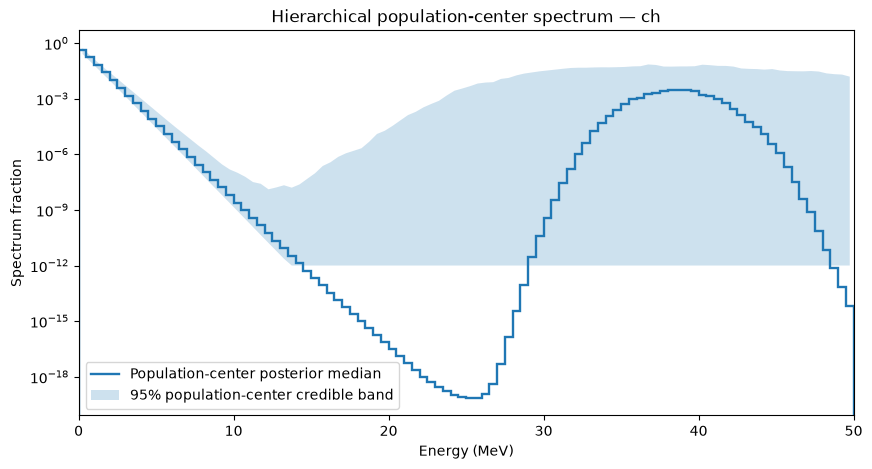


Hierarchical detector-space fit metrics:


,shot,view,valid_channels,median_rms_valid,median_relative_rms_percent,best_posterior_draw_rms_valid,best_posterior_draw_relative_rms_percent
0,10084,ch,200,0.004389,78.389279,0.004344,77.593193
1,11674,ch,200,0.004963,42.277717,0.004911,41.839791
2,11733,ch,200,0.003280,55.149901,0.003233,54.364429
3,11705,ch,200,0.003470,33.132451,0.003443,32.878264
4,11707,ch,200,0.002772,28.597837,0.002717,28.031533
5,11716,ch,200,0.001978,25.615028,0.001965,25.458057


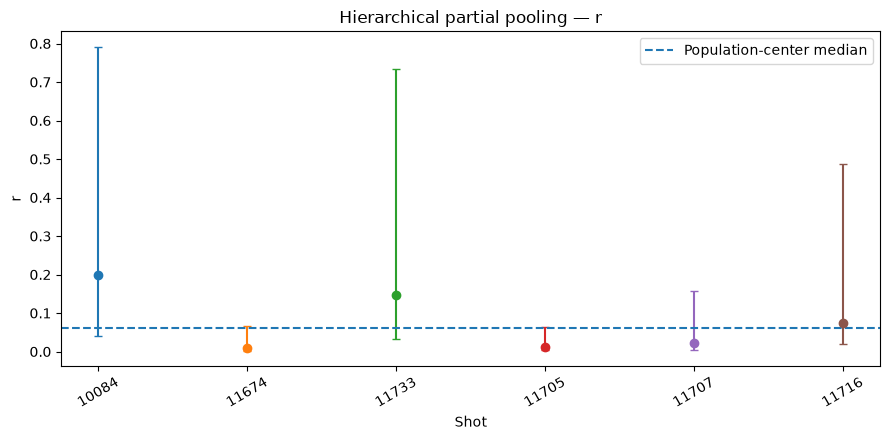

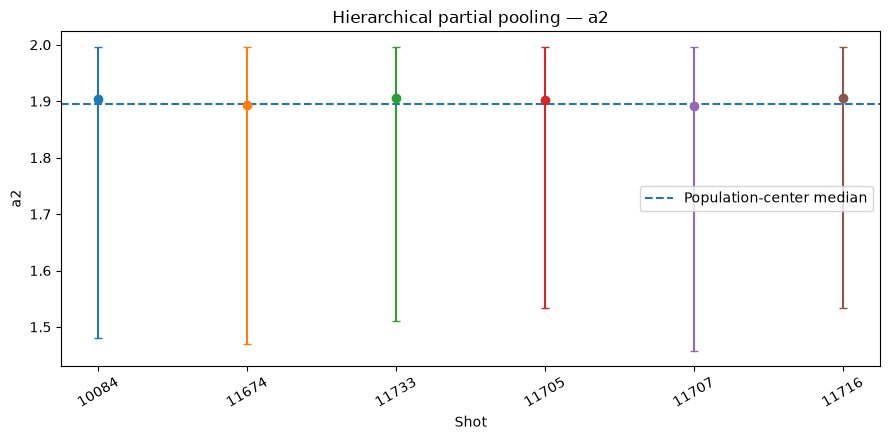

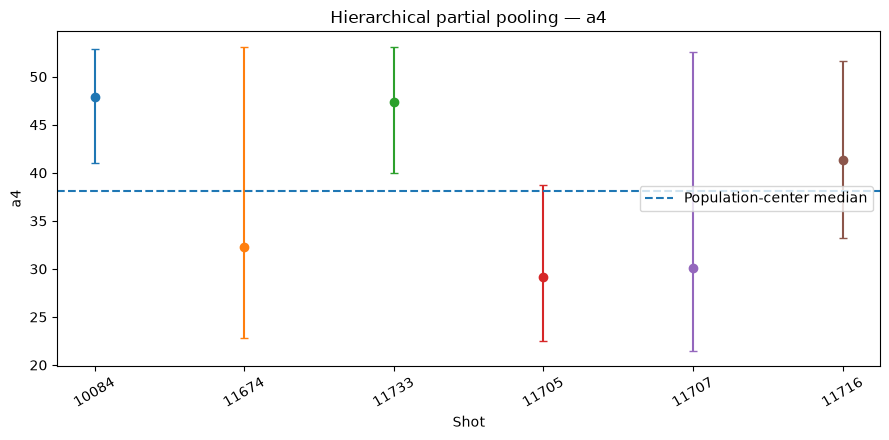

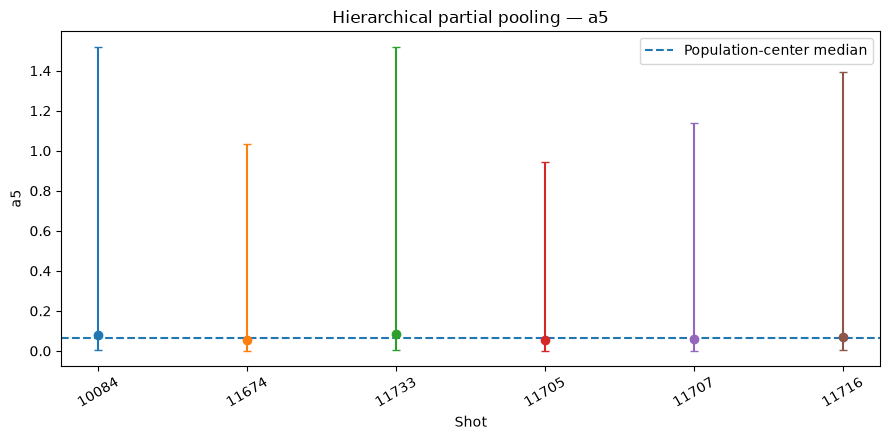

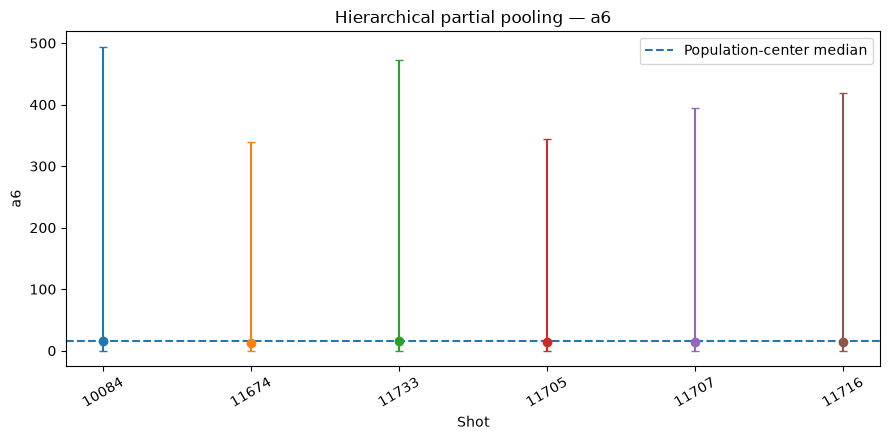


Saved hierarchical results to:
  numpyro_hierarchical_ch
Population summary: numpyro_hierarchical_ch\hierarchical_population_summary_ch.csv
Shot summary: numpyro_hierarchical_ch\hierarchical_shot_summary_ch.csv
Fit metrics: numpyro_hierarchical_ch\hierarchical_fit_metrics_ch.csv
Posterior arrays: numpyro_hierarchical_ch\hierarchical_posterior_ch.npz
Population spectrum: numpyro_hierarchical_ch\hierarchical_population_spectrum_ch.png
Per-shot figures:
  numpyro_hierarchical_ch\hierarchical_infer_10084_ch_n100.png
  numpyro_hierarchical_ch\hierarchical_infer_11674_ch_n100.png
  numpyro_hierarchical_ch\hierarchical_infer_11733_ch_n100.png
  numpyro_hierarchical_ch\hierarchical_infer_11705_ch_n100.png
  numpyro_hierarchical_ch\hierarchical_infer_11707_ch_n100.png
  numpyro_hierarchical_ch\hierarchical_infer_11716_ch_n100.png


In [26]:

# ============================================================================
# HIERARCHICAL MULTI-SHOT INFERENCE
#
# This cell is self-contained with respect to the earlier setup cells:
# run the notebook through the DRM/prior setup first. It does NOT require the
# independent real-shot inference cell to have been executed.
# ============================================================================

from pathlib import Path
import warnings

# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------

HIER_VIEW_TAG = "ch"     # use "ch" or "cv"; do not combine both as independent shots

HIER_SHOT_IDS = [
    "10084",
    "11674",
    "11733",
    "11705",
    "11707",
    "11716",
]

HIER_SHOT_PATHS = [
    f"res/test_images/{shot_id}/{shot_id}_proc_vector_{HIER_VIEW_TAG}.csv"
    for shot_id in HIER_SHOT_IDS
]

HIER_NUM_WARMUP = 1_000
HIER_NUM_SAMPLES = 1_000
HIER_NUM_CHAINS = 4
HIER_TARGET_ACCEPT = 0.99
HIER_MAX_TREE_DEPTH = 12
HIER_MAX_PREDICTIVE_DRAWS = 1_000

HIER_STUDENT_T_DF = 4.0
HIER_SIGMA_PRIOR_SCALE = 0.01

# The hierarchy is built in an unconstrained latent coordinate u.  These
# HalfNormal scales control how much shot-to-shot variation is expected *a priori*.
# Values around 0.5-0.8 are moderate on a logit coordinate; the posterior can
# still infer either much smaller or larger variation if the data support it.
HIER_TAU_PRIOR_SCALE = np.array(
    [0.75, 0.75, 0.75, 0.75, 0.75],
    dtype=np.float64,
)

HIER_PARAMETER_NAMES = [
    "r",
    "a2",
    "a4",
    "a5",
    "a6",
]

HIER_RESULTS_DIR = Path(
    f"numpyro_hierarchical_{HIER_VIEW_TAG}"
)
HIER_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ----------------------------------------------------------------------------
# Priors and physical bounds
# ----------------------------------------------------------------------------

parameter_sampling_h = np.asarray(
    du.PFF_PARAM_SAMPLING,
    dtype=np.float64,
)

# Relative-amplitude prior inherited approximately from the original a3/a1 priors.
R_HIER_PRIOR_MEAN = float(
    parameter_sampling_h[2, 0]
    / parameter_sampling_h[0, 0]
)

R_HIER_PRIOR_STD = float(
    R_HIER_PRIOR_MEAN
    * np.sqrt(
        (parameter_sampling_h[2, 1] / parameter_sampling_h[2, 0]) ** 2
        + (parameter_sampling_h[0, 1] / parameter_sampling_h[0, 0]) ** 2
    )
)
R_HIER_PRIOR_STD = max(
    R_HIER_PRIOR_STD,
    1e-4,
)

R_HIER_LOW = 0.0
R_HIER_HIGH = float(
    parameter_sampling_h[2, 3]
    / parameter_sampling_h[0, 2]
)

hier_prior_mean_physical = np.array(
    [
        R_HIER_PRIOR_MEAN,
        parameter_sampling_h[1, 0],
        parameter_sampling_h[3, 0],
        parameter_sampling_h[4, 0],
        parameter_sampling_h[5, 0],
    ],
    dtype=np.float64,
)

hier_prior_std_physical = np.array(
    [
        R_HIER_PRIOR_STD,
        parameter_sampling_h[1, 1],
        parameter_sampling_h[3, 1],
        parameter_sampling_h[4, 1],
        parameter_sampling_h[5, 1],
    ],
    dtype=np.float64,
)

hier_low = np.array(
    [
        R_HIER_LOW,
        parameter_sampling_h[1, 2],
        parameter_sampling_h[3, 2],
        parameter_sampling_h[4, 2],
        parameter_sampling_h[5, 2],
    ],
    dtype=np.float64,
)

hier_high = np.array(
    [
        R_HIER_HIGH,
        parameter_sampling_h[1, 3],
        parameter_sampling_h[3, 3],
        parameter_sampling_h[4, 3],
        parameter_sampling_h[5, 3],
    ],
    dtype=np.float64,
)

if not np.all(hier_high > hier_low):
    raise ValueError("Every hierarchical parameter must have high > low.")

# ----------------------------------------------------------------------------
# Transform helpers
# ----------------------------------------------------------------------------

def _physical_to_logit(
    x: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
) -> np.ndarray:
    p = (
        (np.asarray(x, dtype=np.float64) - low)
        / (high - low)
    )
    p = np.clip(
        p,
        1e-5,
        1.0 - 1e-5,
    )
    return np.log(
        p / (1.0 - p)
    )


def _logit_to_physical_numpy(
    u: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
) -> np.ndarray:
    u = np.asarray(
        u,
        dtype=np.float64,
    )
    # Numerically stable logistic.
    sigmoid = np.where(
        u >= 0.0,
        1.0 / (1.0 + np.exp(-u)),
        np.exp(u) / (1.0 + np.exp(u)),
    )
    return (
        low
        + (high - low) * sigmoid
    )


# Population-center prior in latent coordinates.
hier_mu_u_loc = _physical_to_logit(
    hier_prior_mean_physical,
    hier_low,
    hier_high,
)

# Delta-method conversion of the original physical prior widths into latent
# coordinate widths. Caps prevent extremely broad original priors from creating
# pathological starting geometry while remaining deliberately weak.
prior_fraction = np.clip(
    (
        hier_prior_mean_physical - hier_low
    )
    / (
        hier_high - hier_low
    ),
    1e-4,
    1.0 - 1e-4,
)

latent_jacobian = (
    1.0
    / (
        (hier_high - hier_low)
        * prior_fraction
        * (1.0 - prior_fraction)
    )
)

hier_mu_u_scale = np.clip(
    hier_prior_std_physical
    * latent_jacobian,
    0.35,
    2.5,
)

print("Hierarchical physical parameters:", HIER_PARAMETER_NAMES)
print("Physical prior centers:", hier_prior_mean_physical)
print("Physical bounds low:", hier_low)
print("Physical bounds high:", hier_high)
print("Latent population-prior centers:", hier_mu_u_loc)
print("Latent population-prior scales:", hier_mu_u_scale)
print("Latent shot-spread prior scales:", HIER_TAU_PRIOR_SCALE)

# ----------------------------------------------------------------------------
# Shot input helpers
# ----------------------------------------------------------------------------

def hierarchical_load_shot_signal(
    csv_path: str | Path,
) -> np.ndarray:
    csv_path = Path(csv_path)

    dataframe = pd.read_csv(
        csv_path
    )

    signal = (
        dataframe.iloc[:, -1]
        .to_numpy(dtype=np.float64)
        .reshape(-1)
    )

    if signal.shape != (200,):
        raise ValueError(
            f"{csv_path}: expected 200 values, got {signal.shape}."
        )

    if not np.all(
        np.isfinite(signal)
    ):
        raise ValueError(
            f"{csv_path}: signal contains NaN or infinite values."
        )

    signal = np.clip(
        signal,
        0.0,
        None,
    )

    total = float(
        signal.sum()
    )

    if total <= 0.0:
        raise ValueError(
            f"{csv_path}: signal has no positive intensity."
        )

    return signal


def hierarchical_l1(
    x: np.ndarray,
) -> np.ndarray:
    x = np.asarray(
        x,
        dtype=np.float64,
    )
    return (
        x
        / max(
            float(x.sum()),
            1e-12,
        )
    )


# Keep only files that actually exist.
hier_existing_paths = [
    Path(path)
    for path in HIER_SHOT_PATHS
    if Path(path).exists()
]

hier_missing_paths = [
    Path(path)
    for path in HIER_SHOT_PATHS
    if not Path(path).exists()
]

if hier_missing_paths:
    print("Skipping missing hierarchical-shot files:")
    for path in hier_missing_paths:
        print("  ", path)

if len(hier_existing_paths) < 2:
    raise FileNotFoundError(
        "Hierarchical inference needs at least two existing shot files. "
        "Edit HIER_SHOT_PATHS/HIER_SHOT_IDS near the top of this cell."
    )

hier_shot_names = [
    path.stem.split("_")[0]
    for path in hier_existing_paths
]

hier_observed = []
hier_valid_masks = []
hier_saturation_masks = []

for path in hier_existing_paths:
    raw_signal = hierarchical_load_shot_signal(
        path
    )

    l1_signal = hierarchical_l1(
        raw_signal
    )

    saturation_mask = du.load_saturation_mask(
        str(path)
    )

    if saturation_mask is None:
        saturation_mask = np.zeros(
            200,
            dtype=bool,
        )

    saturation_mask = np.asarray(
        saturation_mask,
        dtype=bool,
    )

    if saturation_mask.shape != (200,):
        raise ValueError(
            f"{path}: saturation mask has shape {saturation_mask.shape}, expected (200,)."
        )

    hier_observed.append(
        l1_signal
    )
    hier_saturation_masks.append(
        saturation_mask
    )
    hier_valid_masks.append(
        ~saturation_mask
    )

hier_observed = np.stack(
    hier_observed,
    axis=0,
)

hier_valid_masks = np.stack(
    hier_valid_masks,
    axis=0,
)

hier_saturation_masks = np.stack(
    hier_saturation_masks,
    axis=0,
)

N_HIER_SHOTS = hier_observed.shape[0]

print(
    f"Hierarchical group: {N_HIER_SHOTS} shots, view={HIER_VIEW_TAG}"
)
print(
    "Shot names:",
    hier_shot_names,
)
print(
    "Corrected/saturated channel counts:",
    hier_saturation_masks.sum(axis=1).tolist(),
)

# ----------------------------------------------------------------------------
# Hierarchical NumPyro model
# ----------------------------------------------------------------------------

hier_low_jax = jnp.asarray(
    hier_low
)
hier_high_jax = jnp.asarray(
    hier_high
)
hier_mu_u_loc_jax = jnp.asarray(
    hier_mu_u_loc
)
hier_mu_u_scale_jax = jnp.asarray(
    hier_mu_u_scale
)
hier_tau_scale_jax = jnp.asarray(
    HIER_TAU_PRIOR_SCALE
)

hier_drm_jax = jnp.asarray(
    drm_binned
)
hier_energy_jax = jnp.maximum(
    jnp.asarray(
        energy_bins
    ),
    1e-12,
)


def hierarchical_bayesian_model(
    detector_observation=None,
    valid_channel_mask=None,
):
    n_shots = detector_observation.shape[0]

    # Population center in unconstrained coordinates.
    mu_u = numpyro.sample(
        "mu_u",
        dist.Normal(
            hier_mu_u_loc_jax,
            hier_mu_u_scale_jax,
        ).to_event(1),
    )

    # Population shot-to-shot spread in the same latent coordinates.
    tau_u = numpyro.sample(
        "tau_u",
        dist.HalfNormal(
            hier_tau_scale_jax
        ).to_event(1),
    )

    # Non-centered shot offsets. This avoids a classic hierarchical funnel.
    shot_z = numpyro.sample(
        "shot_z",
        dist.Normal(
            jnp.zeros(
                (n_shots, len(HIER_PARAMETER_NAMES))
            ),
            jnp.ones(
                (n_shots, len(HIER_PARAMETER_NAMES))
            ),
        ).to_event(2),
    )

    shot_u = (
        mu_u[None, :]
        + tau_u[None, :] * shot_z
    )

    shot_theta = (
        hier_low_jax[None, :]
        + (
            hier_high_jax - hier_low_jax
        )[None, :]
        * jax.nn.sigmoid(
            shot_u
        )
    )

    # Shot-specific measurement/model mismatch scale.
    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(
            HIER_SIGMA_PRIOR_SCALE
        )
        .expand(
            [n_shots]
        )
        .to_event(1),
    )

    r = shot_theta[:, 0][:, None]
    a2 = shot_theta[:, 1][:, None]
    a4 = shot_theta[:, 2][:, None]
    a5 = shot_theta[:, 3][:, None]
    a6 = shot_theta[:, 4][:, None]

    E = hier_energy_jax[None, :]

    denominator = jnp.maximum(
        a5 * E
        + a6 / E,
        1e-12,
    )

    spectra = (
        jnp.exp(
            -a2 * E
        )
        + r
        * jnp.exp(
            -(
                (E - a4) ** 2
            )
            / denominator
        )
    )

    spectra = jnp.maximum(
        spectra,
        1e-12,
    )

    # Shape-only detector forward model for every shot.
    predicted_raw = (
        spectra
        @ hier_drm_jax.T
    )

    predicted_l1 = (
        predicted_raw
        / jnp.maximum(
            jnp.sum(
                predicted_raw,
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )
    )

    channel_log_probability = (
        dist.StudentT(
            df=HIER_STUDENT_T_DF,
            loc=predicted_l1,
            scale=sigma[:, None] + 1e-7,
        )
        .log_prob(
            detector_observation
        )
    )

    if valid_channel_mask is not None:
        channel_log_probability = jnp.where(
            valid_channel_mask,
            channel_log_probability,
            0.0,
        )

    numpyro.factor(
        "joint_detector_log_likelihood",
        jnp.sum(
            channel_log_probability
        ),
    )


hier_kernel = NUTS(
    hierarchical_bayesian_model,
    target_accept_prob=HIER_TARGET_ACCEPT,
    dense_mass=True,
    max_tree_depth=HIER_MAX_TREE_DEPTH,
)

hier_mcmc = MCMC(
    hier_kernel,
    num_warmup=HIER_NUM_WARMUP,
    num_samples=HIER_NUM_SAMPLES,
    num_chains=HIER_NUM_CHAINS,
    chain_method="sequential",
    progress_bar=True,
)

hier_mcmc.run(
    random.key(
        SEED + 8_000
    ),
    detector_observation=jnp.asarray(
        hier_observed
    ),
    valid_channel_mask=jnp.asarray(
        hier_valid_masks
    ),
)

hier_mcmc.print_summary()

# ----------------------------------------------------------------------------
# Divergence diagnostics
# ----------------------------------------------------------------------------

hier_extra_fields = hier_mcmc.get_extra_fields(
    group_by_chain=True
)

hier_diverging = np.asarray(
    hier_extra_fields["diverging"]
)

hier_total_divergences = int(
    hier_diverging.sum()
)

print("\n" + "=" * 76)
print("HIERARCHICAL NUTS DIVERGENCE DIAGNOSTIC")
print("=" * 76)
print(
    f"Total divergences: "
    f"{hier_total_divergences}/{hier_diverging.size}"
)

if hier_diverging.ndim >= 2:
    for chain_index in range(
        hier_diverging.shape[0]
    ):
        chain_count = int(
            hier_diverging[
                chain_index
            ].sum()
        )
        print(
            f"Chain {chain_index + 1}: "
            f"{chain_count}/{hier_diverging.shape[1]}"
        )

if hier_total_divergences == 0:
    print("Status: GOOD — no divergent transitions detected.")
else:
    print(
        "Status: WARNING — divergences remain. "
        "Do not interpret a narrow hierarchical credible interval as trustworthy "
        "until the sampler geometry is fixed."
    )
print("=" * 76)

hier_posterior = hier_mcmc.get_samples(
    group_by_chain=False
)

# ----------------------------------------------------------------------------
# Convert latent posterior samples back to physical parameters
# ----------------------------------------------------------------------------

hier_mu_u_draws = np.asarray(
    hier_posterior["mu_u"]
)

hier_tau_u_draws = np.asarray(
    hier_posterior["tau_u"]
)

hier_shot_z_draws = np.asarray(
    hier_posterior["shot_z"]
)

hier_sigma_draws = np.asarray(
    hier_posterior["sigma"]
)

hier_population_theta = _logit_to_physical_numpy(
    hier_mu_u_draws,
    hier_low,
    hier_high,
)

hier_shot_u_draws = (
    hier_mu_u_draws[:, None, :]
    + hier_tau_u_draws[:, None, :]
    * hier_shot_z_draws
)

hier_shot_theta = _logit_to_physical_numpy(
    hier_shot_u_draws,
    hier_low,
    hier_high,
)

# shapes:
# population_theta -> (posterior_draws, 5)
# shot_theta       -> (posterior_draws, n_shots, 5)

# ----------------------------------------------------------------------------
# Population and shot-specific summaries
# ----------------------------------------------------------------------------

def _credible_summary(
    values: np.ndarray,
) -> dict:
    values = np.asarray(
        values,
        dtype=np.float64,
    )
    return {
        "mean": float(
            np.mean(values)
        ),
        "std": float(
            np.std(values)
        ),
        "median": float(
            np.median(values)
        ),
        "credible_2.5%": float(
            np.percentile(
                values,
                2.5,
            )
        ),
        "credible_16%": float(
            np.percentile(
                values,
                16.0,
            )
        ),
        "credible_84%": float(
            np.percentile(
                values,
                84.0,
            )
        ),
        "credible_97.5%": float(
            np.percentile(
                values,
                97.5,
            )
        ),
    }


population_rows = []

for parameter_index, name in enumerate(
    HIER_PARAMETER_NAMES
):
    row = {
        "parameter": name,
    }
    row.update(
        _credible_summary(
            hier_population_theta[
                :,
                parameter_index,
            ]
        )
    )
    row["tau_latent_median"] = float(
        np.median(
            hier_tau_u_draws[
                :,
                parameter_index,
            ]
        )
    )
    row["tau_latent_2.5%"] = float(
        np.percentile(
            hier_tau_u_draws[
                :,
                parameter_index,
            ],
            2.5,
        )
    )
    row["tau_latent_97.5%"] = float(
        np.percentile(
            hier_tau_u_draws[
                :,
                parameter_index,
            ],
            97.5,
        )
    )
    population_rows.append(
        row
    )

hier_population_summary = pd.DataFrame(
    population_rows
)

print("\nPopulation-center posterior:")
display(
    hier_population_summary
)

shot_parameter_rows = []

for shot_index, shot_name in enumerate(
    hier_shot_names
):
    for parameter_index, parameter_name in enumerate(
        HIER_PARAMETER_NAMES
    ):
        row = {
            "shot": shot_name,
            "view": HIER_VIEW_TAG,
            "parameter": parameter_name,
        }
        row.update(
            _credible_summary(
                hier_shot_theta[
                    :,
                    shot_index,
                    parameter_index,
                ]
            )
        )
        shot_parameter_rows.append(
            row
        )

    sigma_row = {
        "shot": shot_name,
        "view": HIER_VIEW_TAG,
        "parameter": "sigma",
    }
    sigma_row.update(
        _credible_summary(
            hier_sigma_draws[
                :,
                shot_index,
            ]
        )
    )
    shot_parameter_rows.append(
        sigma_row
    )

hier_shot_summary = pd.DataFrame(
    shot_parameter_rows
)

print("\nShot-specific posterior parameters:")
display(
    hier_shot_summary
)

# ----------------------------------------------------------------------------
# Posterior spectra and detector forward draws
# ----------------------------------------------------------------------------

hier_rng = np.random.default_rng(
    SEED + 8_500
)

hier_available_draws = (
    hier_shot_theta.shape[0]
)

hier_draw_count = min(
    hier_available_draws,
    HIER_MAX_PREDICTIVE_DRAWS,
)

hier_selected_draws = hier_rng.choice(
    hier_available_draws,
    size=hier_draw_count,
    replace=False,
)

theta_selected = hier_shot_theta[
    hier_selected_draws
]

population_theta_selected = hier_population_theta[
    hier_selected_draws
]

E_np = np.maximum(
    np.asarray(
        energy_bins,
        dtype=np.float64,
    ),
    1e-12,
)

# Shot-specific spectra: (draw, shot, energy)
r = theta_selected[:, :, 0][:, :, None]
a2 = theta_selected[:, :, 1][:, :, None]
a4 = theta_selected[:, :, 2][:, :, None]
a5 = theta_selected[:, :, 3][:, :, None]
a6 = theta_selected[:, :, 4][:, :, None]

E3 = E_np[None, None, :]

denominator = np.maximum(
    a5 * E3
    + a6 / E3,
    1e-12,
)

hier_spectra = (
    np.exp(
        -a2 * E3
    )
    + r
    * np.exp(
        -(
            (E3 - a4) ** 2
        )
        / denominator
    )
)

hier_spectra = np.maximum(
    hier_spectra,
    0.0,
)

hier_spectra_l1 = (
    hier_spectra
    / np.maximum(
        hier_spectra.sum(
            axis=2,
            keepdims=True,
        ),
        1e-12,
    )
)

hier_detector = np.einsum(
    "dse,ce->dsc",
    hier_spectra,
    np.asarray(
        drm_binned,
        dtype=np.float64,
    ),
)

hier_detector_l1 = (
    hier_detector
    / np.maximum(
        hier_detector.sum(
            axis=2,
            keepdims=True,
        ),
        1e-12,
    )
)

# Population-center spectrum draws.
pr = population_theta_selected[:, 0][:, None]
pa2 = population_theta_selected[:, 1][:, None]
pa4 = population_theta_selected[:, 2][:, None]
pa5 = population_theta_selected[:, 3][:, None]
pa6 = population_theta_selected[:, 4][:, None]

E2 = E_np[None, :]

pdenominator = np.maximum(
    pa5 * E2
    + pa6 / E2,
    1e-12,
)

population_spectra = (
    np.exp(
        -pa2 * E2
    )
    + pr
    * np.exp(
        -(
            (E2 - pa4) ** 2
        )
        / pdenominator
    )
)

population_spectra_l1 = (
    population_spectra
    / np.maximum(
        population_spectra.sum(
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )
)

population_spectrum_median = np.median(
    population_spectra_l1,
    axis=0,
)

population_spectrum_low = np.percentile(
    population_spectra_l1,
    2.5,
    axis=0,
)

population_spectrum_high = np.percentile(
    population_spectra_l1,
    97.5,
    axis=0,
)

# ----------------------------------------------------------------------------
# Population spectrum plot
# ----------------------------------------------------------------------------

energy_edges_h = np.linspace(
    0.0,
    50.0,
    len(energy_bins) + 1,
)

plt.figure(
    figsize=(10, 5)
)

plt.stairs(
    population_spectrum_median,
    energy_edges_h,
    linewidth=1.7,
    label="Population-center posterior median",
)

plt.fill_between(
    energy_bins,
    np.maximum(
        population_spectrum_low,
        1e-12,
    ),
    np.maximum(
        population_spectrum_high,
        1e-12,
    ),
    alpha=0.22,
    label="95% population-center credible band",
)

plt.yscale(
    "log"
)
plt.xlim(
    0.0,
    50.0,
)
plt.xlabel(
    "Energy (MeV)"
)
plt.ylabel(
    "Spectrum fraction"
)
plt.title(
    f"Hierarchical population-center spectrum — {HIER_VIEW_TAG}"
)
plt.legend()

hier_population_figure_path = (
    HIER_RESULTS_DIR
    / f"hierarchical_population_spectrum_{HIER_VIEW_TAG}.png"
)

plt.savefig(
    hier_population_figure_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# ----------------------------------------------------------------------------
# Per-shot posterior plots + residual metrics
# ----------------------------------------------------------------------------

hier_metric_rows = []
hier_main_figure_paths = []

channels_h = np.arange(
    1,
    201,
)

for shot_index, shot_name in enumerate(
    hier_shot_names
):
    signal_l1 = hier_observed[
        shot_index
    ]

    valid = hier_valid_masks[
        shot_index
    ]

    saturation_mask = hier_saturation_masks[
        shot_index
    ]

    shot_spectrum_draws = hier_spectra_l1[
        :,
        shot_index,
        :,
    ]

    shot_detector_draws = hier_detector_l1[
        :,
        shot_index,
        :,
    ]

    spectrum_median = np.median(
        shot_spectrum_draws,
        axis=0,
    )
    spectrum_low = np.percentile(
        shot_spectrum_draws,
        2.5,
        axis=0,
    )
    spectrum_high = np.percentile(
        shot_spectrum_draws,
        97.5,
        axis=0,
    )

    detector_median = np.median(
        shot_detector_draws,
        axis=0,
    )
    detector_low = np.percentile(
        shot_detector_draws,
        2.5,
        axis=0,
    )
    detector_high = np.percentile(
        shot_detector_draws,
        97.5,
        axis=0,
    )

    residual_draws = (
        signal_l1[None, :]
        - shot_detector_draws
    )

    residual_median = np.median(
        residual_draws,
        axis=0,
    )
    residual_low = np.percentile(
        residual_draws,
        2.5,
        axis=0,
    )
    residual_high = np.percentile(
        residual_draws,
        97.5,
        axis=0,
    )

    median_rms_valid = float(
        np.sqrt(
            np.mean(
                (
                    signal_l1[valid]
                    - detector_median[valid]
                ) ** 2
            )
        )
    )

    signal_rms_valid = float(
        np.sqrt(
            np.mean(
                signal_l1[valid] ** 2
            )
        )
    )

    # Best detector-space posterior draw. This is reported separately from the
    # Bayesian posterior median rather than replacing it.
    draw_rms_valid = np.sqrt(
        np.mean(
            (
                shot_detector_draws[:, valid]
                - signal_l1[None, valid]
            ) ** 2,
            axis=1,
        )
    )

    best_draw_index = int(
        np.argmin(
            draw_rms_valid
        )
    )

    best_rms_valid = float(
        draw_rms_valid[
            best_draw_index
        ]
    )

    best_detector = shot_detector_draws[
        best_draw_index
    ]

    best_spectrum = shot_spectrum_draws[
        best_draw_index
    ]

    relative_median_rms = float(
        100.0
        * median_rms_valid
        / max(
            signal_rms_valid,
            1e-12,
        )
    )

    relative_best_rms = float(
        100.0
        * best_rms_valid
        / max(
            signal_rms_valid,
            1e-12,
        )
    )

    hier_metric_rows.append(
        {
            "shot": shot_name,
            "view": HIER_VIEW_TAG,
            "valid_channels": int(
                valid.sum()
            ),
            "median_rms_valid": median_rms_valid,
            "median_relative_rms_percent": relative_median_rms,
            "best_posterior_draw_rms_valid": best_rms_valid,
            "best_posterior_draw_relative_rms_percent": relative_best_rms,
        }
    )

    figure, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        tight_layout=True,
    )

    figure.suptitle(
        f"Hierarchical NumPyro inference — "
        f"shot {shot_name}_{HIER_VIEW_TAG} "
        f"(n_bins={len(energy_bins)})",
        fontsize=12,
    )

    # Detector response.
    axes[0].plot(
        channels_h,
        signal_l1,
        linewidth=1.4,
        label="Real signal (L1)",
    )

    axes[0].plot(
        channels_h,
        detector_median,
        linestyle="--",
        linewidth=1.3,
        label=(
            "Hierarchical posterior median "
            f"({relative_median_rms:.1f}% RMS)"
        ),
    )

    axes[0].plot(
        channels_h,
        best_detector,
        linestyle=":",
        linewidth=1.1,
        label=(
            "Best posterior draw "
            f"({relative_best_rms:.1f}% RMS)"
        ),
    )

    axes[0].fill_between(
        channels_h,
        detector_low,
        detector_high,
        alpha=0.22,
        label="95% hierarchical credible band",
    )

    axes[0].set_xlabel(
        "Effective detector pixel"
    )
    axes[0].set_ylabel(
        "L1-normalized response"
    )
    axes[0].set_title(
        "Detector response"
    )
    axes[0].legend()

    # Spectrum.
    axes[1].stairs(
        spectrum_median,
        energy_edges_h,
        linewidth=1.7,
        label="Hierarchical posterior median spectrum",
    )

    axes[1].plot(
        energy_bins,
        best_spectrum,
        linestyle=":",
        linewidth=1.1,
        label="Best detector-RMS posterior spectrum",
    )

    axes[1].fill_between(
        energy_bins,
        np.maximum(
            spectrum_low,
            1e-12,
        ),
        np.maximum(
            spectrum_high,
            1e-12,
        ),
        alpha=0.22,
        label="95% hierarchical credible band",
    )

    axes[1].set_yscale(
        "log"
    )
    axes[1].set_xlim(
        0.0,
        50.0,
    )
    axes[1].set_xlabel(
        "Energy (MeV)"
    )
    axes[1].set_ylabel(
        "Spectrum fraction"
    )
    axes[1].set_title(
        "Incident gamma-ray spectrum"
    )
    axes[1].legend()

    # Residual.
    axes[2].plot(
        channels_h,
        residual_median,
        linewidth=1.0,
        label="Posterior median residual",
    )

    axes[2].fill_between(
        channels_h,
        residual_low,
        residual_high,
        alpha=0.22,
        label="95% residual interval",
    )

    axes[2].axhline(
        0.0,
        linestyle="--",
        linewidth=0.8,
    )

    if saturation_mask.any():
        change_indices = np.flatnonzero(
            np.diff(
                np.r_[
                    0,
                    saturation_mask.astype(int),
                    0,
                ]
            )
        )
        spans = change_indices.reshape(
            -1,
            2,
        )
        for span_index, (
            lower_index,
            upper_index,
        ) in enumerate(spans):
            axes[2].axvspan(
                channels_h[lower_index],
                channels_h[upper_index - 1],
                alpha=0.15,
                label=(
                    "Saturation-corrected"
                    if span_index == 0
                    else None
                ),
            )

    axes[2].set_xlabel(
        "Effective detector pixel"
    )
    axes[2].set_ylabel(
        "Real L1 − predicted L1"
    )
    axes[2].set_title(
        "Detector-response residual"
    )
    axes[2].legend()

    figure_path = (
        HIER_RESULTS_DIR
        / (
            f"hierarchical_infer_"
            f"{shot_name}_{HIER_VIEW_TAG}"
            f"_n{len(energy_bins)}.png"
        )
    )

    figure.savefig(
        figure_path,
        dpi=160,
    )
    plt.close(
        figure
    )

    hier_main_figure_paths.append(
        figure_path
    )

hier_metrics = pd.DataFrame(
    hier_metric_rows
)

print("\nHierarchical detector-space fit metrics:")
display(
    hier_metrics
)

# ----------------------------------------------------------------------------
# Shrinkage / partial-pooling plots
# ----------------------------------------------------------------------------

for parameter_index, parameter_name in enumerate(
    HIER_PARAMETER_NAMES
):
    plt.figure(
        figsize=(9, 4.5)
    )

    for shot_index, shot_name in enumerate(
        hier_shot_names
    ):
        values = hier_shot_theta[
            :,
            shot_index,
            parameter_index,
        ]

        median_value = np.median(
            values
        )

        low_value = np.percentile(
            values,
            2.5,
        )

        high_value = np.percentile(
            values,
            97.5,
        )

        plt.errorbar(
            shot_index,
            median_value,
            yerr=np.array(
                [
                    [
                        median_value - low_value
                    ],
                    [
                        high_value - median_value
                    ],
                ]
            ),
            fmt="o",
            capsize=3,
        )

    population_median = np.median(
        hier_population_theta[
            :,
            parameter_index,
        ]
    )

    plt.axhline(
        population_median,
        linestyle="--",
        label="Population-center median",
    )

    plt.xticks(
        np.arange(
            len(hier_shot_names)
        ),
        hier_shot_names,
        rotation=30,
    )

    plt.ylabel(
        parameter_name
    )

    plt.xlabel(
        "Shot"
    )

    plt.title(
        f"Hierarchical partial pooling — {parameter_name}"
    )

    plt.legend()
    plt.tight_layout()

    shrinkage_path = (
        HIER_RESULTS_DIR
        / (
            f"hierarchical_shrinkage_"
            f"{parameter_name}_{HIER_VIEW_TAG}.png"
        )
    )

    plt.savefig(
        shrinkage_path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

# ----------------------------------------------------------------------------
# Save numerical results
# ----------------------------------------------------------------------------

population_summary_path = (
    HIER_RESULTS_DIR
    / f"hierarchical_population_summary_{HIER_VIEW_TAG}.csv"
)

shot_summary_path = (
    HIER_RESULTS_DIR
    / f"hierarchical_shot_summary_{HIER_VIEW_TAG}.csv"
)

metrics_path = (
    HIER_RESULTS_DIR
    / f"hierarchical_fit_metrics_{HIER_VIEW_TAG}.csv"
)

hier_population_summary.to_csv(
    population_summary_path,
    index=False,
)

hier_shot_summary.to_csv(
    shot_summary_path,
    index=False,
)

hier_metrics.to_csv(
    metrics_path,
    index=False,
)

npz_path = (
    HIER_RESULTS_DIR
    / f"hierarchical_posterior_{HIER_VIEW_TAG}.npz"
)

np.savez_compressed(
    npz_path,
    shot_names=np.asarray(
        hier_shot_names
    ),
    parameter_names=np.asarray(
        HIER_PARAMETER_NAMES
    ),
    population_theta=hier_population_theta,
    tau_u=hier_tau_u_draws,
    shot_theta=hier_shot_theta,
    sigma=hier_sigma_draws,
    observed=hier_observed,
    valid_masks=hier_valid_masks,
    total_divergences=hier_total_divergences,
    energy_bins=np.asarray(
        energy_bins
    ),
)

print("\nSaved hierarchical results to:")
print(" ", HIER_RESULTS_DIR)
print("Population summary:", population_summary_path)
print("Shot summary:", shot_summary_path)
print("Fit metrics:", metrics_path)
print("Posterior arrays:", npz_path)
print("Population spectrum:", hier_population_figure_path)
print("Per-shot figures:")
for path in hier_main_figure_paths:
    print(" ", path)



## How to interpret the hierarchical output

The most important new quantities are the population spreads `tau_u`.

- **Small `tau_u`** for a parameter: the shots strongly agree and partial pooling
  should noticeably narrow the shot-specific posterior.
- **Large `tau_u`**: the shots genuinely prefer different values, so the hierarchy
  correctly avoids forcing them to share one spectrum.
- **A wide population credible interval with a small shot spread** means the whole
  experiment still lacks information about that parameter.
- **A narrow population interval with large shot spread** means the average behavior
  is known but individual shots differ.

The per-shot figures report both:

1. the **hierarchical posterior median** spectrum/forward response; and
2. the **best detector-RMS posterior draw**.

The latter is useful for checking the lowest residual attainable *within the
hierarchical PFF posterior*, but it should not replace the posterior median and
credible interval when reporting Bayesian uncertainty.

### To run the other correction/view

Change:

```python
HIER_VIEW_TAG = "ch"
```

to:

```python
HIER_VIEW_TAG = "cv"
```

and rerun the hierarchical cell. The results will be written to a separate
`numpyro_hierarchical_cv` directory.
